In [1]:
#Importing libraries
!pip install pandas sqlalchemy pymysql
from sqlalchemy import create_engine

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
db_user = "USER NAME"
db_password = "PASSWORD"
db_host = "HOST"        
db_port = "PORT NO"             
db_name = "ecom"            

#Creating the connection string and engine
connection_string = f"mysql+pymysql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
engine = create_engine(connection_string)

#SQL Query
query = "SELECT * FROM olist_master;"

#Loading the data into a Pandas DataFrame
print("Connecting to MySQL and loading data... this might take a moment.")
df = pd.read_sql(query, engine)

print("Data successfully loaded!")

Connecting to MySQL and loading data... this might take a moment.
Data successfully loaded!


In [3]:
# Checking the shape
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset contains 99252 rows and 34 columns.



In [4]:
#Checking sample row
display(df.head())

,customer_id,customer_unique_id,customer_zip_code,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_payment_value,payment_type,payment_installments,payment_rows,total_items,total_items_price,total_freight_value,primary_seller_id,primary_product_id,seller_zip_code,seller_city,seller_state,product_category_name_pt,product_category_name_en,product_weight_gm,product_photos_qty,product_name_length,product_description_length,review_score,review_creation_date,customer_lat,customer_lng
0,081a2d41949e652a50988fd39febb4a8,d462d9e30ff3df8b64ade2aac3cafc7a,04963,sao paulo,SP,0071ee2429bc1efdc43aa3e073a5290e,delivered,2018-01-22 11:08:15,2018-01-22 14:17:41,2018-01-26 15:12:17,2018-01-31 23:58:36,2018-02-15,192.44,voucher,1.0,2.0,1.0,179.98,12.46,53e4c6e0f4312d4d2107a8c9cddf45cd,00ffe57f0110d73fd84d162252b2c784,13920,pedreira,SP,utilidades_domesticas,housewares\r,16000.0,1.0,56.0,1877.0,4,2018-02-01,-23.749260,-46.779099
1,21307401801cf2242315563c89d8b9fb,bfe8411cb6fed718c3879fac9847f23f,03375,sao paulo,SP,01358622f65717728b3b2ec2cf4e8812,delivered,2017-10-28 22:00:08,2017-10-28 22:10:14,2017-10-30 18:45:28,2017-10-31 18:08:15,2017-11-10,21.77,credit_card,1.0,2.0,1.0,13.99,7.78,3c7c4a49ec3c6550809089c6a2ca9370,017692475c1c954ff597feda05131d73,03804,sao paulo,SP,perfumaria,perfumery\r,50.0,1.0,54.0,933.0,3,2017-11-01,-23.573997,-46.548755
2,24436139c80a4ae51c0e3a98469ed7d4,b2c2e2635aded82494c5be5843664b74,03690,sao paulo,SP,0044c6f6d22dd280534344177c81b989,delivered,2018-05-18 16:59:09,2018-05-18 17:15:37,2018-05-21 14:46:00,2018-06-04 20:12:57,2018-06-12,196.07,credit_card,1.0,1.0,1.0,179.93,16.14,06e5eefc71ec47ae763c5c6f8db7064f,01cf56cd6138b926a4802d16fc304149,91350,porto alegre,RS,eletronicos,electronics\r,100.0,6.0,43.0,3023.0,4,2018-06-05,-23.528460,-46.478316
3,5848ef3f994e18c5121d291e0daedc81,7e59d854b9bb4cbb2c85fcd93877c694,08527,ferraz de vasconcelos,SP,00526a9d4ebde463baee25f386963ddc,delivered,2018-08-07 22:03:44,2018-08-07 22:15:22,2018-08-08 14:11:00,2018-08-16 19:58:24,2018-08-15,169.16,credit_card,3.0,1.0,4.0,135.56,33.60,7210cd29727d674c00741e5e387b3ccd,0c4a0f8ab44f9acd2d04e7024f9ba362,03279,sao paulo,SP,alimentos,food\r,388.0,1.0,49.0,740.0,1,2018-08-17,-23.553694,-46.378928
4,625686f10cec48c80b355bdcd4b94dd8,308821e781e809311898edd3769315d0,05271,sao paulo,SP,02e827a9f1e829b50b81eb9e26588ed9,delivered,2017-08-11 18:32:57,2017-08-11 18:50:14,2017-08-16 21:04:10,2017-08-18 18:47:05,2017-08-24,67.68,credit_card,1.0,1.0,1.0,59.90,7.78,8f119a0aee85c0c8fc534629734e94fd,009af1277432f1a05742df69cdf72d1e,06440,barueri,SP,brinquedos,toys\r,700.0,3.0,58.0,916.0,3,2017-08-19,-23.429710,-46.794230


In [5]:
#Checking datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99252 entries, 0 to 99251
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   customer_id                    99252 non-null  object        
 1   customer_unique_id             99252 non-null  object        
 2   customer_zip_code              99252 non-null  object        
 3   customer_city                  99252 non-null  object        
 4   customer_state                 99252 non-null  object        
 5   order_id                       99252 non-null  object        
 6   order_status                   99252 non-null  object        
 7   order_purchase_timestamp       99252 non-null  datetime64[ns]
 8   order_approved_at              99092 non-null  datetime64[ns]
 9   order_delivered_carrier_date   97469 non-null  datetime64[ns]
 10  order_delivered_customer_date  96288 non-null  datetime64[ns]
 11  order_estimated

In [6]:
#Checking for Nulls
df.isnull().sum()

customer_id                         0
customer_unique_id                  0
customer_zip_code                   0
customer_city                       0
customer_state                      0
order_id                            0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2964
order_estimated_delivery_date       0
total_payment_value                 1
payment_type                        1
payment_installments                1
payment_rows                        1
total_items                       775
total_items_price                 775
total_freight_value               775
primary_seller_id                 775
primary_product_id                775
seller_zip_code                   775
seller_city                       775
seller_state                      775
product_category_name_pt          775
product_category_name_en         2193
product_weig

In [7]:
#Statistical check
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_payment_value,payment_installments,payment_rows,total_items,total_items_price,total_freight_value,product_weight_gm,product_photos_qty,product_name_length,product_description_length,review_creation_date,customer_lat,customer_lng
count,99252,99092,97469,96288,99252,99251.000000,99251.000000,99251.000000,98477.000000,98477.000000,98477.000000,98455.000000,98477.000000,98477.000000,98477.000000,98485,98973.000000,98973.000000
mean,2017-12-31 02:45:55.939638528,2017-12-31 12:38:19.651112192,2018-01-04 15:57:54.276241664,2018-01-14 06:22:07.249003008,2018-01-23 21:12:59.542981376,161.018079,2.929693,1.044745,1.141515,137.786262,22.818615,2115.634950,2.218356,48.150715,783.629538,2018-01-12 22:59:40.736152832,-21.193478,-46.175793
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.000000,0.000000,1.000000,1.000000,0.850000,0.000000,2.000000,0.000000,0.000000,0.000000,2016-10-02 00:00:00,-33.689948,-72.668881
25%,2017-09-12 13:06:27,2017-09-12 20:48:57.750000128,2017-09-15 21:13:36,2017-09-25 21:21:41.500000,2017-10-03 00:00:00,62.000000,1.000000,1.000000,1.000000,45.900000,13.850000,300.000000,1.000000,42.000000,341.000000,2017-09-23 00:00:00,-23.589279,-48.097775
50%,2018-01-18 17:10:21.500000,2018-01-19 02:37:14,2018-01-24 01:57:25,2018-02-02 16:22:31,2018-02-15 00:00:00,105.290000,2.000000,1.000000,1.000000,86.900000,17.160000,700.000000,1.000000,52.000000,601.000000,2018-02-02 00:00:00,-22.925943,-46.630801
75%,2018-05-04 08:51:34.500000,2018-05-04 12:51:56,2018-05-08 11:55:00,2018-05-15 19:44:32.750000128,2018-05-25 00:00:00,176.970000,4.000000,1.000000,1.000000,149.900000,24.030000,1825.000000,3.000000,57.000000,990.000000,2018-05-16 00:00:00,-20.140216,-43.598897
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,13664.080000,24.000000,29.000000,21.000000,13440.000000,1794.960000,40425.000000,20.000000,76.000000,3992.000000,2018-08-31 00:00:00,3.842508,-34.799346
std,NaN,NaN,NaN,NaN,NaN,222.095041,2.715763,0.381384,0.537911,210.782142,21.657470,3777.981601,1.754367,11.500063,657.348988,NaN,5.597969,4.051550


In [8]:
# Converting to numeric, coercing errors to NaN, then cast to nullable Integer
df['review_score'] = pd.to_numeric(df['review_score'], errors='coerce').astype('Int64')

# verifying
print(df['review_score'].dtype)

Int64


In [9]:
df['product_category_name_en'] = df['product_category_name_en'].str.replace('\r', '')

# Univariate Analysis

**NUMERIC DATA ANALYSIS**

**Histogram distribution**

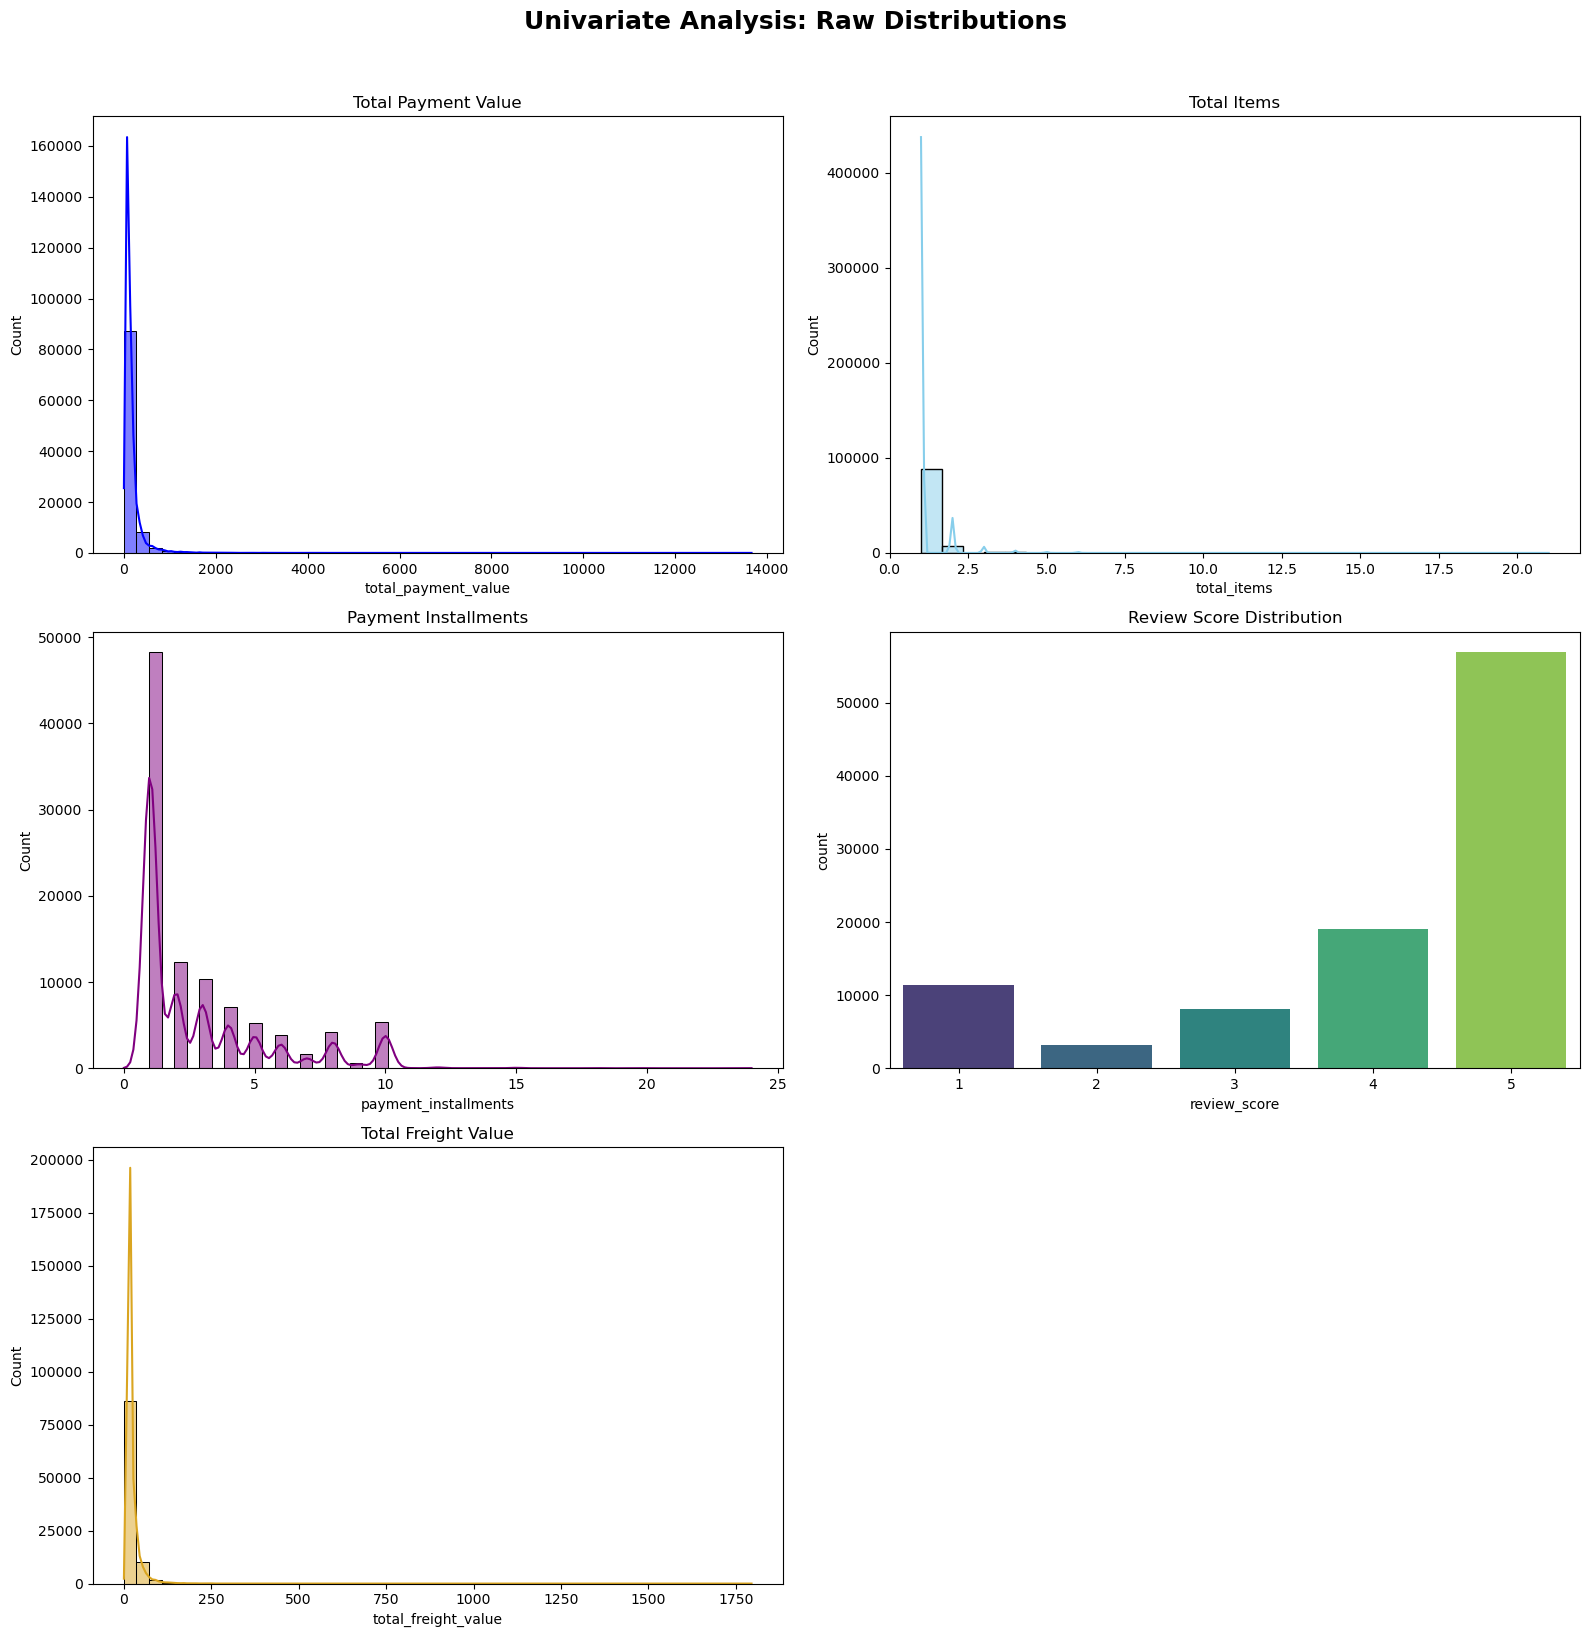

In [10]:
#Histogram Plot
fig, axes = plt.subplots(3, 2, figsize=(16, 16)) 
fig.suptitle('Univariate Analysis: Raw Distributions', fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten()

sns.histplot(data=df, x='total_payment_value', bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Total Payment Value')

sns.histplot(data=df, x='total_items', bins=30, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Total Items')

sns.histplot(data=df, x='payment_installments', bins=50, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Payment Installments')

sns.countplot(data=df.dropna(subset=['review_score']), x='review_score', ax=axes[3], palette='viridis')
axes[3].set_title('Review Score Distribution')

sns.histplot(data=df, x='total_freight_value', bins=50, kde=True, ax=axes[4], color='goldenrod')
axes[4].set_title('Total Freight Value')

axes[5].axis('off')

# Clean up layout and display
plt.tight_layout()
plt.show()

**Percentiles check**

In [11]:
#Percentiles for Price, Freight, and Weight
cols_to_check = ['total_payment_value', 'total_items', 'payment_installments', 'total_freight_value']

print("--- PERCENTILES FOR TOTAL PAYMENT, TOTAL ITEMS, PAYMENT INSTALLMENTS AND TOTAL FREIGHT VALUE ---")
print(df[cols_to_check].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

--- PERCENTILES FOR TOTAL PAYMENT, TOTAL ITEMS, PAYMENT INSTALLMENTS AND TOTAL FREIGHT VALUE ---
       total_payment_value   total_items  payment_installments  \
count         99251.000000  98477.000000          99251.000000   
mean            161.018079      1.141515              2.929693   
std             222.095041      0.537911              2.715763   
min               0.000000      1.000000              0.000000   
50%             105.290000      1.000000              2.000000   
75%             176.970000      1.000000              4.000000   
90%             308.300000      1.000000              8.000000   
95%             453.515000      2.000000             10.000000   
99%            1076.605000      3.000000             10.000000   
max           13664.080000     21.000000             24.000000   

       total_freight_value  
count         98477.000000  
mean             22.818615  
std              21.657470  
min               0.000000  
50%              17.160000  
75

**Outliers checking (Top 1%)**

In [12]:
#Total Payment Value
#Extracting Top 1%
p99_payment = df['total_payment_value'].quantile(0.99)
payment_top1 = df[df['total_payment_value'] > p99_payment]

print('---Top 1% of TOTAL PAYMENT Summary Statistics---')
print(payment_top1['total_payment_value'].describe())

#Top transactions
print('\n---Top Transactions---')
print(payment_top1[['customer_unique_id','order_id','total_payment_value','total_items','product_category_name_en',
                    'order_status']].sort_values(by='total_payment_value',ascending=False).head(20))

#Product Category Distribution
print('\n---Product Category Distribution---')
print(payment_top1.groupby('product_category_name_en')['total_payment_value'].agg(['count','mean','max']).sort_values(
      'count',ascending=False))

#Order Status
print('\n---Order Status---')
#Calculating counts and raw percentages
counts = payment_top1['order_status'].value_counts()
percents = payment_top1['order_status'].value_counts(normalize=True) * 100
#Combining them into a DataFrame
status_summary = pd.DataFrame({'Count': counts,'Percentage': percents.round(2).astype(str) + '%'})
#Printing the combined table
print(status_summary)

---Top 1% of TOTAL PAYMENT Summary Statistics---
count      993.000000
mean      1693.909235
std        798.680253
min       1076.760000
25%       1240.850000
50%       1439.270000
75%       1925.770000
max      13664.080000
Name: total_payment_value, dtype: float64

---Top Transactions---
                     customer_unique_id                          order_id  \
66516  0a0a92112bd4c708ca5fde585afaa872  03caa2c082116e1d31e67e9ae3700499   
41567  763c8b1c9c68a0229c42c9fc6f662b93  736e1922ae60d0d6a89247b851902527   
63350  dc4802a71eae9be1dd28f5d788ceb526  0812eb902a67711a1cb742b3cdaa65ae   
31183  459bef486812aa25204be022145caa62  fefacc66af859508bf1a7934eab1e97f   
74298  ff4159b92c40ebe40454e3e6a7c35ed6  f5136e38d1a14a4dbd87dff67da82701   
29628  4007669dec559734d6f53e029e360987  2cc9089445046817a7539d90805e6e5a   
68791  da122df9eeddfedc1dc1f5349a1a690c  a96610ab360d42a2e5335a3998b4718a   
64845  5d0a2980b292d049061542014e8960bf  b4c4b76c642808cbe472a32b86cddc95   
38986  eebb5dda1

In [13]:
#Total Items

p99_items = df['total_items'].quantile(0.99)
items_top1 = df[df['total_items'] > p99_items]

#Basket Size Distribution
print('\n---Basket Size Distribution---')
print(items_top1['total_items'].value_counts().sort_index())

#Product Categories
print('\n---Product Categories---')
print(items_top1.groupby('product_category_name_en')['total_items'].count().sort_values(ascending=False))

#Payment Comparison
print('\n---Payment Comparison---')
print(items_top1[['total_items','total_payment_value']].describe())



---Basket Size Distribution---
total_items
4.0     504
5.0     203
6.0     197
7.0      21
8.0       8
9.0       3
10.0      8
11.0      4
12.0      5
13.0      1
14.0      2
15.0      2
20.0      2
21.0      1
Name: count, dtype: int64

---Product Categories---
product_category_name_en
furniture_decor                            144
bed_bath_table                              99
computers_accessories                       98
housewares                                  98
garden_tools                                64
office_furniture                            53
health_beauty                               52
sports_leisure                              51
auto                                        26
watches_gifts                               22
telephony                                   17
baby                                        17
construction_tools_construction             17
pet_shop                                    13
perfumery                                   12
statio

In [14]:
#Payment installments
p99_installments = df['payment_installments'].quantile(0.99)

installment_top1 = df[df['payment_installments'] > p99_installments]

#Distribution
print('\n---Distribution---')
print(installment_top1['payment_installments'].value_counts().sort_index())

print('\n---Distribution Payment_installments & Total Payment ---')
print(installment_top1.groupby('payment_installments')['total_payment_value'].sum())

#Payment values
print('\n---Payment Values---')
print(installment_top1[['payment_installments', 'total_payment_value']].describe())

#Product Categories
print('\n---Product Categories---')
print(installment_top1.groupby('product_category_name_en')['payment_installments'].count())


---Distribution---
payment_installments
11.0     23
12.0    133
13.0     16
14.0     15
15.0     74
16.0      5
17.0      8
18.0     26
20.0     17
21.0      3
22.0      1
23.0      1
24.0     18
Name: count, dtype: int64

---Distribution Payment_installments & Total Payment ---
payment_installments
11.0     2873.44
12.0    42965.91
13.0     2407.40
14.0     2644.66
15.0    33100.23
16.0     1463.47
17.0     1396.82
18.0    12837.15
20.0    10468.63
21.0      731.10
22.0      228.71
23.0      236.48
24.0    11133.93
Name: total_payment_value, dtype: float64

---Payment Values---
       payment_installments  total_payment_value
count            340.000000           340.000000
mean              14.532353           360.258618
std                3.411176           356.823052
min               11.000000           110.300000
25%               12.000000           155.130000
50%               13.000000           215.320000
75%               15.000000           405.510000
max               24.

In [15]:
p99_freight = df['total_freight_value'].quantile(0.99)
freight_top1 = df[df['total_freight_value'] > p99_freight]

#Freight Summary
print('\n---Freight Summary---')
print(freight_top1['total_freight_value'].describe())

#Product Categories
print('\n---Product Categories---')
print(freight_top1.groupby('product_category_name_en')['total_freight_value'].agg(['count','mean','max']).sort_values(
    'count',ascending=False))

#Seller State
print('\n---Seller State---')
print(freight_top1.groupby('seller_state')['total_freight_value'].count().sort_values(ascending=False))

#Customer State
print('\n---Customer State---')
print(freight_top1.groupby('customer_state')['total_freight_value'].count().sort_values(ascending=False))


---Freight Summary---
count     985.000000
mean      161.507858
std        87.801326
min       104.990000
25%       118.080000
50%       137.040000
75%       173.430000
max      1794.960000
Name: total_freight_value, dtype: float64

---Product Categories---
                                         count        mean      max
product_category_name_en                                           
office_furniture                           118  181.397119   626.64
housewares                                  95  159.649368   458.73
furniture_decor                             91  167.717033  1002.29
health_beauty                               76  176.935000   497.42
sports_leisure                              63  151.632540   436.24
auto                                        61  148.706885   383.64
bed_bath_table                              48  145.278125   260.12
computers_accessories                       43  147.335116   388.10
garden_tools                                42  132.941905   

**Boxplot**

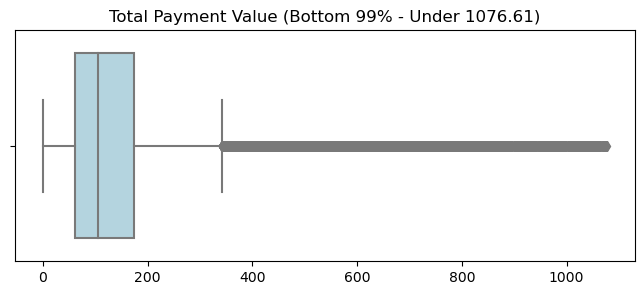

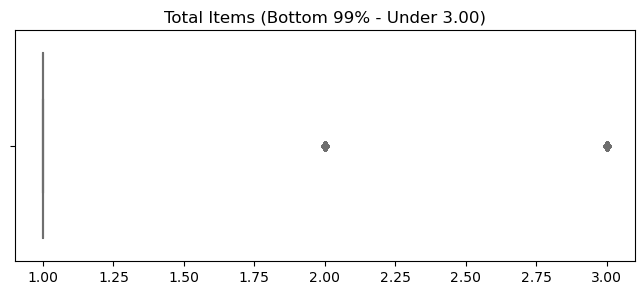

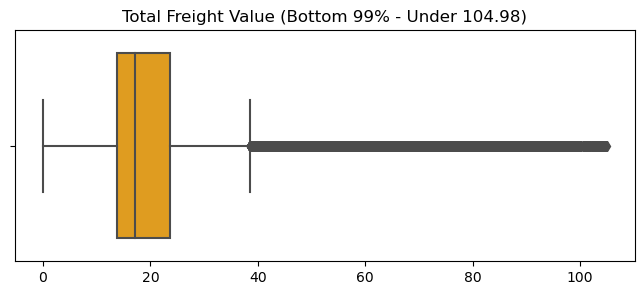

In [16]:
#PLotting Boxplots
#Total Payment Value
plt.figure(figsize=(8, 3))
p99_payment = df['total_payment_value'].quantile(0.99)
filtered_payment = df[df['total_payment_value'] <= p99_payment]

sns.boxplot(x=filtered_payment['total_payment_value'], color='lightblue')
plt.title(f'Total Payment Value (Bottom 99% - Under {p99_payment:.2f})')
plt.xlabel('')
plt.show()

#Total Items
plt.figure(figsize=(8, 3))
p99_items = df['total_items'].quantile(0.99)
filtered_items = df[df['total_items'] <= p99_items]

sns.boxplot(x=filtered_items['total_items'], color='skyblue')
plt.title(f'Total Items (Bottom 99% - Under {p99_items:.2f})')
plt.xlabel('')
plt.show()

#Payment Installments Boxplot
plt.figure(figsize=(8, 3))
p99_price = df['total_freight_value'].quantile(0.99)
filtered_price = df[df['total_freight_value'] <= p99_price]

sns.boxplot(x=filtered_price['total_freight_value'], color='orange')
plt.title(f'Total Freight Value (Bottom 99% - Under {p99_price:.2f})')
plt.xlabel('')
plt.show()

**Excluding Top 1% distribution check**

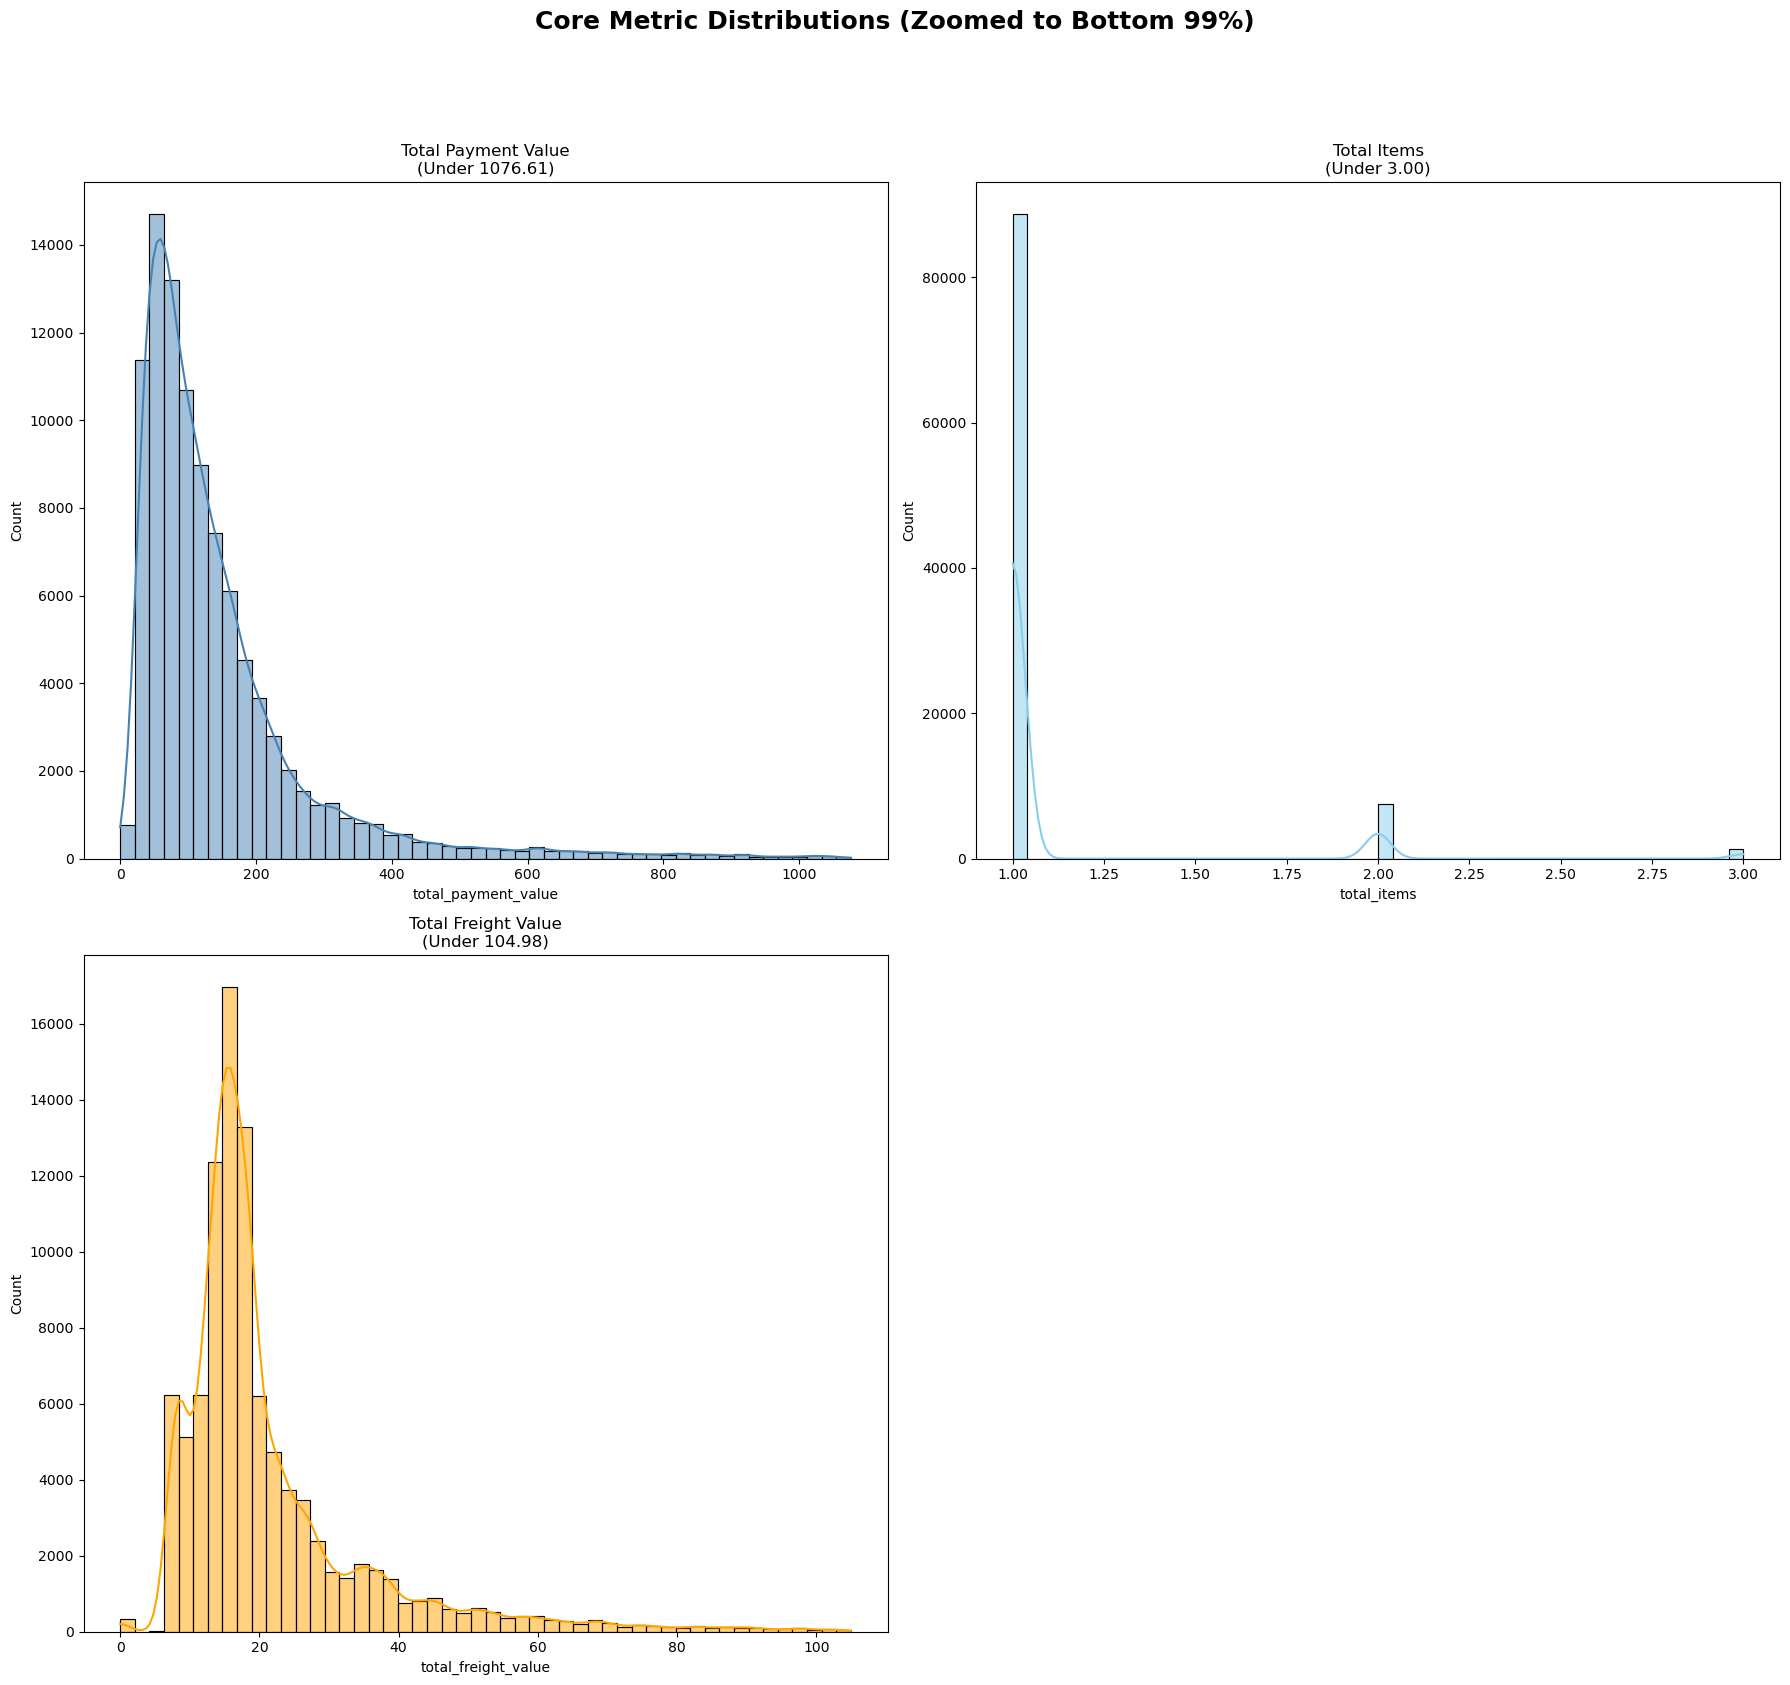

In [17]:
# 1. Create a canvas with 1 Row and 3 Columns
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('Core Metric Distributions (Zoomed to Bottom 99%)', fontsize=18, fontweight='bold', y=1.05)

axes = axes.flatten()

#Payment Value
p99_pay = df['total_payment_value'].quantile(0.99)
sns.histplot(data=df[df['total_payment_value'] <= p99_pay], x='total_payment_value', bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Total Payment Value\n(Under {p99_pay:.2f})')

#Total Items
p99_items = df['total_items'].quantile(0.99)
sns.histplot(data=df[df['total_items'] <= p99_items], x='total_items', bins=50, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title(f'Total Items\n(Under {p99_items:.2f})')

#Total Freight Value
p99_total_freight = df['total_freight_value'].quantile(0.99)
sns.histplot(data=df[df['total_freight_value'] <= p99_total_freight], x='total_freight_value', bins=50, kde=True, ax=axes[2], color='orange')
axes[2].set_title(f'Total Freight Value\n(Under {p99_total_freight:.2f})')

fig.delaxes(axes[3])

plt.tight_layout()
plt.show()

**Insights:**

**1. Total Payment Value:** 
* The Payment value is heavily right-skewed. While the Average Payment value is 161, the median is much lower at 105, indicating a high volume of small ticket purchases.
   
**Decision:** The top 1% transactions(above 1076) stretch up to 13,664. These extreme high-value orders are capped at the 99th percentile for visualization to avoid skewing standard behavioral models. 

**Validation:** Business validation confirmed that these high-value transactions were primarily associated with premium product categories and delivered orders, indicating genuine customer purchases rather than data anomalies.
   
**2. Total Items:**
* The Total items indicated that Olist functions overwhelming as a single item marketplace. Over 90% of orders contains exactly 1 item, and 99% of orders contains 3 or fewer items.
   
**Decision:** Bulk purchases (e,g., 21 items) are extremely rare, The focus of further analysis will remain on standard consumer behavior (1-3 items).

**Validation:** Top 1% basket-size orders were concentrated in categories such as Furniture, Housewares, and Computer Accessories, confirming that larger baskets represent legitimate purchasing behaviour rather than data-quality issues.
   
**3. Payment Installments:**
* There is a strong reliance on credit and EMI structuring. While single-payment is the most common, there are significant spikes at 2, 3, 4, 8, and 10 installments.

**Decision:** This heavy utilization of structured payment plans highlights a price-sensitive consumer base. Transactions above 10 installments (up to 24) account for less than 1% of the data and are treated as outliers.

**Validation:** Business validation showed that higher installment counts were mainly associated with high-value product categories such as Furniture, Computers, and Housewares, confirming valid financing behaviour.

**4. Review Score:**
* More than 50,000 review score are given 5 & more than 20,000 review scores are given 4, reflecting highly positive Ecommerce platform. Some reviews are under 12,000 1 & ewer than 5,000 reviews are given a 2, indicating that when customers are unhappy, their experience is overwhelmingly negative (1-star).

**Decision:** There is a concerning, distinct spike in 1-star reviews. This confirms the core hypothesis that a specific failure point in the customer journey is driving severe dissatisfaction, rather than generalized mediocrity.

**5. Total Freight Value:**
* The Freight value is heavily right-skewed. While the Average Freight value is 22, the median is much lower at 17, indicating a high volume of lower freight charges.

**Decision:** The top 1% of freight charges (above 104) stretch up to 1,794. These extreme logistical outliers are capped at the 99th percentile for visualization to focus on standard shipping behavior.

**Validation:** High freight charges were predominantly associated with bulky product categories and major seller/customer states, confirming that these represent legitimate logistics scenarios rather than anomalous records.

**Categorical data Analysis**

In [18]:
#All categories
full_cols = ['order_status', 'payment_type']

for col in full_cols:
    print(f"--- All {col} ---")
    print(df[col].value_counts())
    print()

#Top 10 categories
top_10_cols = ['customer_state', 'seller_state', 'product_category_name_en']

for col in top_10_cols:
    print(f"--- Top 10 {col} ---")
    print(df[col].value_counts().head(10))
    print()

--- All order_status ---
order_status
delivered      96290
shipped         1106
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

--- All payment_type ---
payment_type
credit_card    74086
boleto         19777
voucher         3862
debit_card      1523
not_defined        3
Name: count, dtype: int64

--- Top 10 customer_state ---
customer_state
SP    41680
RJ    12832
MG    11608
RS     5449
PR     5034
SC     3625
BA     3376
DF     2137
ES     2027
GO     2013
Name: count, dtype: int64

--- Top 10 seller_state ---
seller_state
SP    69816
MG     7835
PR     7590
RJ     4303
SC     3614
RS     1966
DF      821
BA      565
GO      459
PE      403
Name: count, dtype: int64

--- Top 10 product_category_name_en ---
product_category_name_en
bed_bath_table           9312
health_beauty            8783
sports_leisure           7673
computers_accessories    6660
furniture_decor          6310
ho

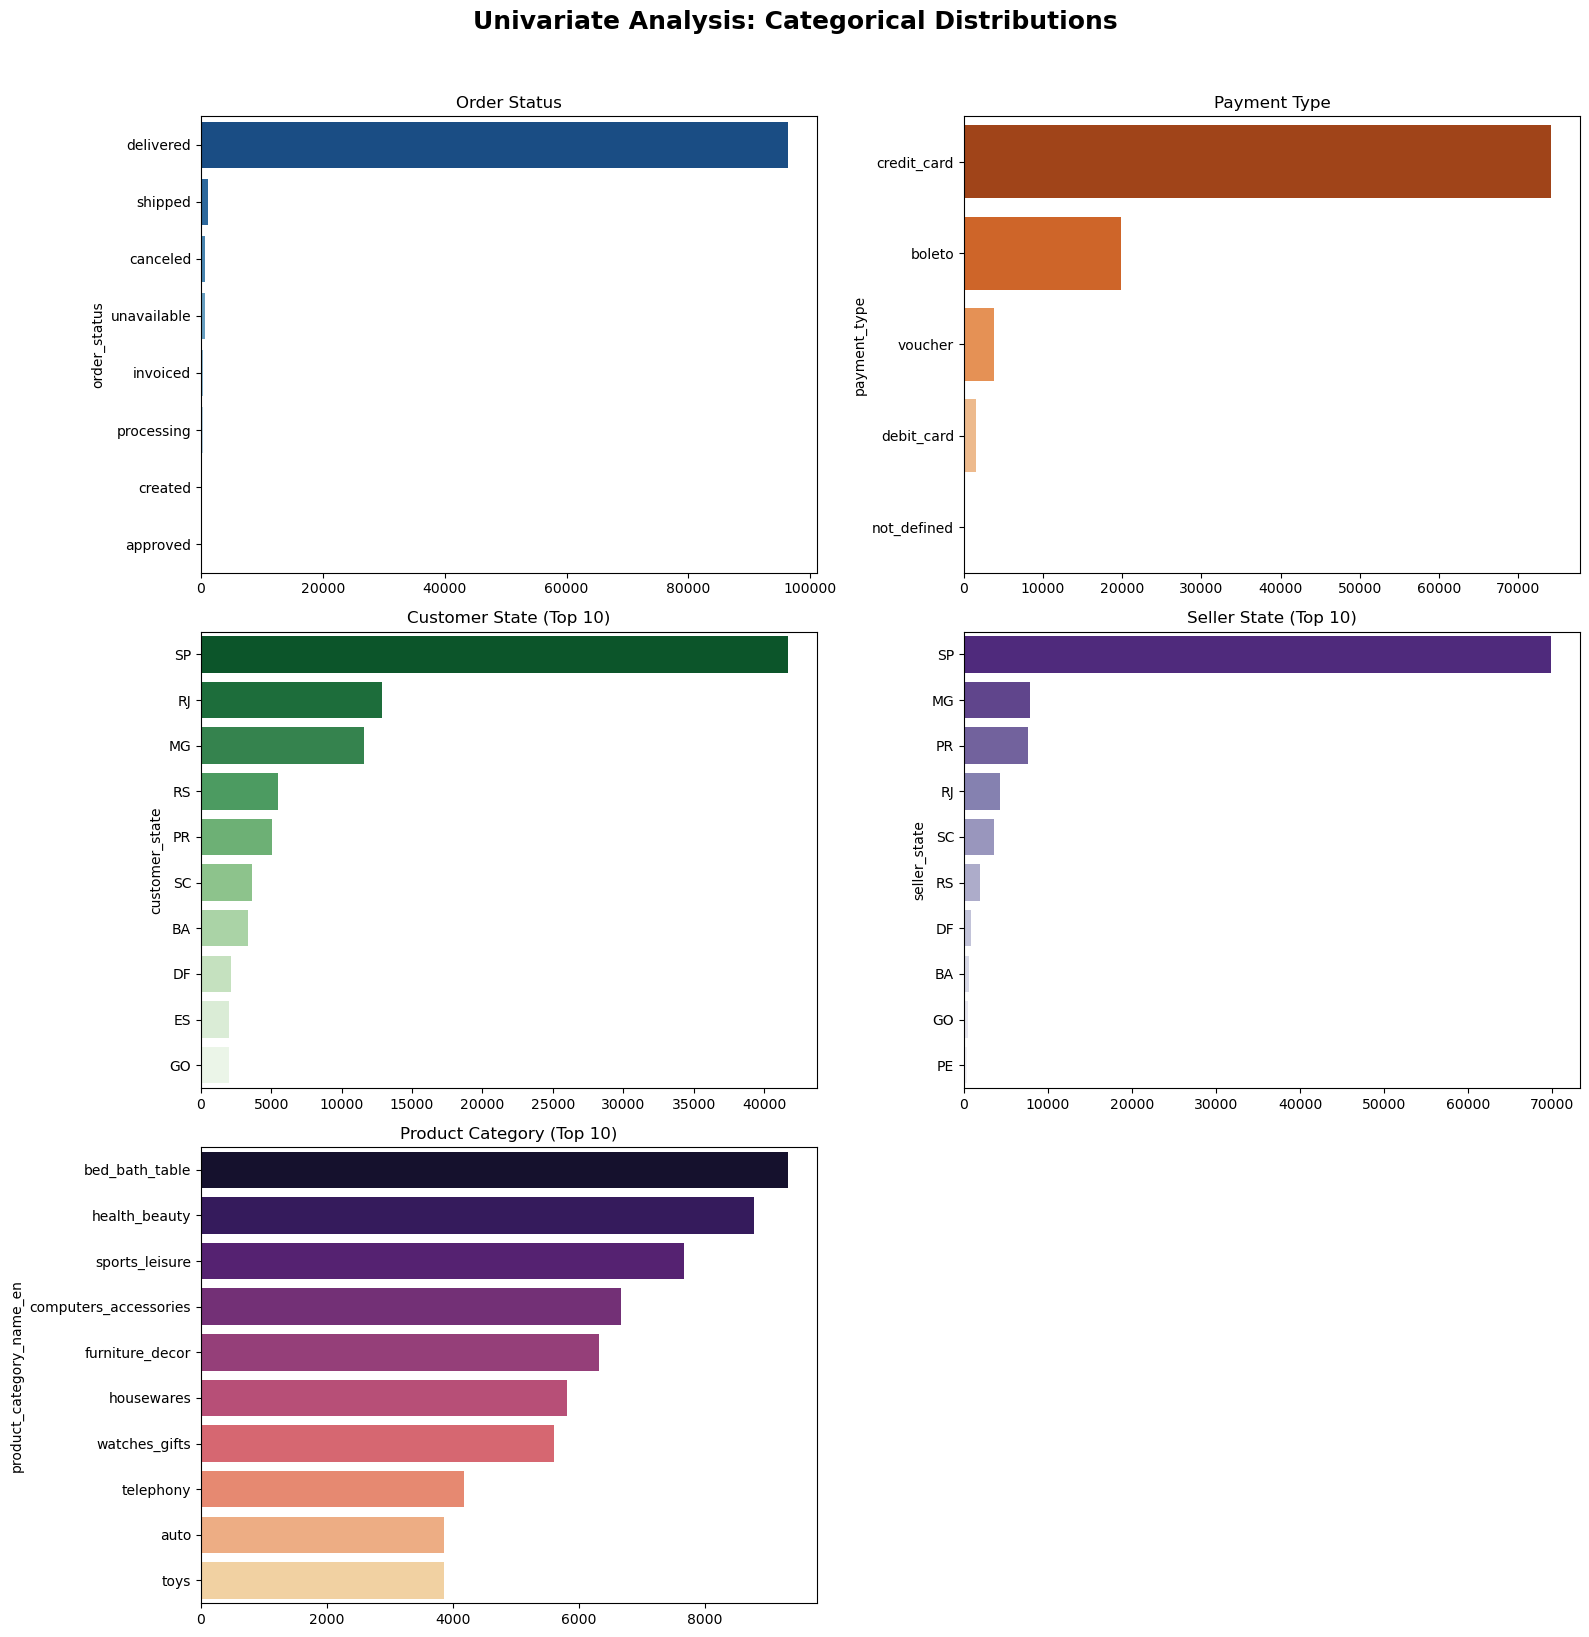

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16)) 
fig.suptitle('Univariate Analysis: Categorical Distributions', fontsize=18, fontweight='bold', y=1.02)

# FLATTEN turns this into a 1D list: axes[0], axes[1], axes[2], axes[3], axes[4], axes[5]
axes = axes.flatten()

# Plot 1 (Index 0)
status_counts = df['order_status'].value_counts()
sns.barplot(x=status_counts.values, y=status_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Order Status')

# Plot 2 (Index 1)
payment_counts = df['payment_type'].value_counts()
sns.barplot(x=payment_counts.values, y=payment_counts.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Payment Type')

# Plot 3 (Index 2)
cust_state_counts = df['customer_state'].value_counts().head(10)
sns.barplot(x=cust_state_counts.values, y=cust_state_counts.index, ax=axes[2], palette='Greens_r')
axes[2].set_title('Customer State (Top 10)')

# Plot 4 (Index 3)
seller_state_counts = df['seller_state'].value_counts().head(10)
sns.barplot(x=seller_state_counts.values, y=seller_state_counts.index, ax=axes[3], palette='Purples_r')
axes[3].set_title('Seller State (Top 10)')

# Plot 5 (Index 4)
category_counts = df['product_category_name_en'].value_counts().head(10)
sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[4], palette='magma')
axes[4].set_title('Product Category (Top 10)')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**1. Order Status**

* Over 97% of the dataset consists of delivered orders.

* Insight: The data is highly stable and represents completed customer journeys. Canceled or unavailable orders are present but make up a negligible fraction of the historical data.

**2. Payment Type**

* credit_card is the overwhelmingly dominant payment method (accounting for roughly 75% of transactions), followed distantly by boleto (a popular Brazilian cash-payment ticket).

* Insight: Customers heavily prefer credit, which aligns with the previous finding that EMI (Installment) payments are highly utilized.

**3. Customer vs. Seller Geography**

* Customers: While distributed across Brazil, the state of SP (São Paulo) holds a massive lead, followed by RJ (Rio de Janeiro) and MG (Minas Gerais).

* Sellers: The seller distribution is even more extreme. SP accounts for nearly 70,000 sellers, while the second-place state (MG) has fewer than 8,000.

* Insight: Olist is highly centralized in São Paulo. This massive geographical imbalance suggests that shipping to non-SP states will likely incur higher freight costs and longer delivery days, establishing a strong potential hypothesis for churn.

**4. Product Categories**

* The top-selling categories are bed_bath_table, health_beauty, and sports_leisure.

* Insight: Olist functions primarily as a lifestyle and home-goods marketplace. These items vary wildly in size and weight, which will heavily impact freight logistics.

**Date & Time data Analysis**

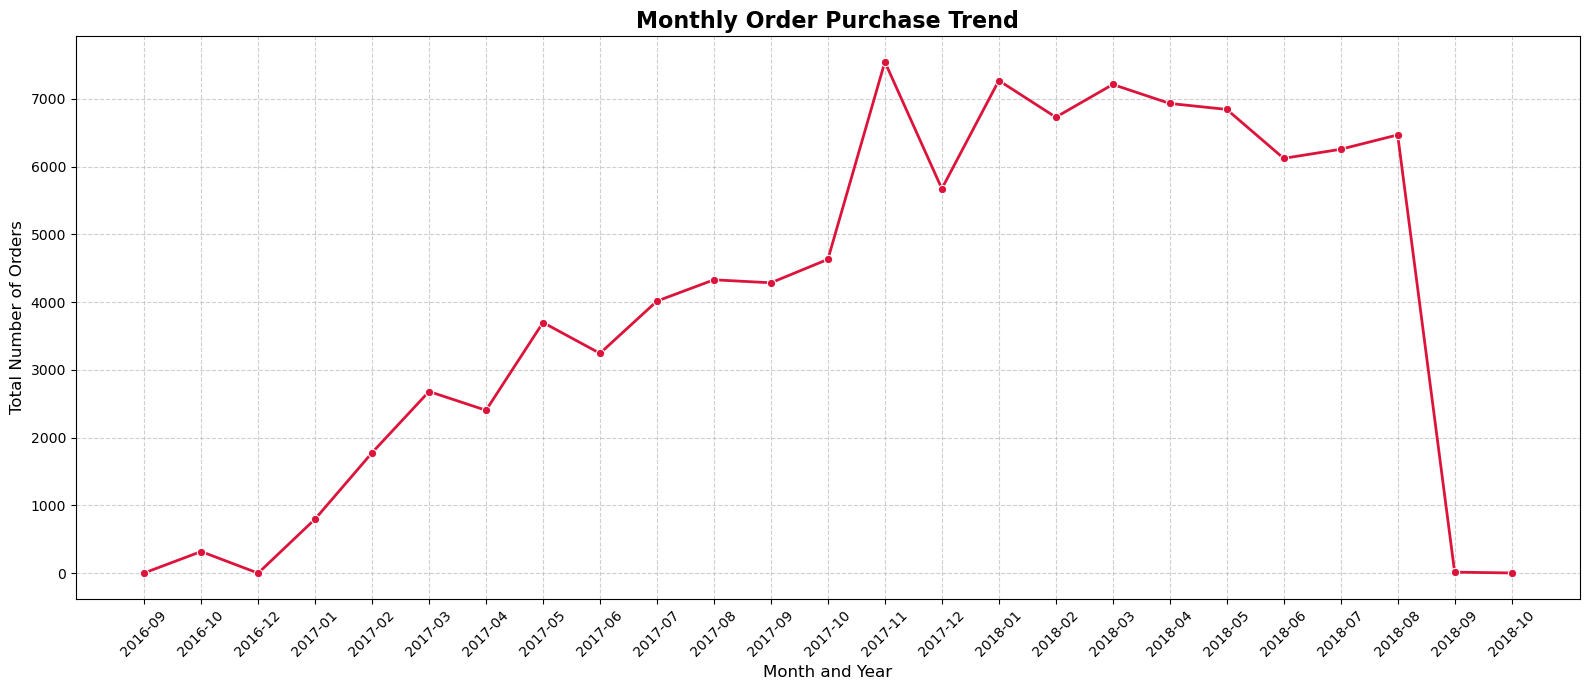

--- RAW MONTHLY COUNTS ---
purchase_month
2016-09       4
2016-10     320
2016-12       1
2017-01     799
2017-02    1778
2017-03    2681
2017-04    2404
2017-05    3699
2017-06    3244
2017-07    4015
2017-08    4329
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6931
2018-05    6843
2018-06    6121
2018-07    6255
2018-08    6467
2018-09      16
2018-10       4
Name: count, dtype: int64


In [20]:
#Creating a new column with just the Year and Month (e.g., '2017-10')
df['purchase_month'] = df['order_purchase_timestamp'].dt.strftime('%Y-%m')

#Counting how many orders happened in each month and sort them chronologically
monthly_orders = df['purchase_month'].value_counts().sort_index()

#Drawing the Line Chart
plt.figure(figsize=(16, 7))
sns.lineplot(x=monthly_orders.index, y=monthly_orders.values, marker='o', color='crimson', linewidth=2)

plt.title('Monthly Order Purchase Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month and Year', fontsize=12)
plt.ylabel('Total Number of Orders', fontsize=12)
plt.xticks(rotation=45) # Tilting the dates so they don't overlap!
plt.grid(True, linestyle='--', alpha=0.6) # Adding a faint grid to help read the numbers

plt.tight_layout()
plt.show()

# Printing the raw numbers below the chart
print("--- RAW MONTHLY COUNTS ---")
print(monthly_orders)

**Insights:**

* There is a massive, defining spike in November 2017, reaching a peak of 7,544 orders.
* Before Nov 2017, the platform was slowly growing from ~800 to ~4,600 orders per month. After Nov 2017, the volume never dropped below 5,600, maintaining a strong, steady run-rate of 6,000–7,200 orders per month throughout 2018
* The data at the very beginning (Sept-Dec 2016) and the very end (Sept-Oct 2018) show near-zero order volumes (e.g., 1 order in Dec 2016, 4 orders in Oct 2018).

**Actionable Decision:** When calculating monthly averages later, these "fringe" months (Late 2016 and late 2018) must be filtered out, or they will heavily skew the results downward.

# Feature Engineering

**Delivery Date Features**

In [21]:
#Delivery Date Subtractions

#F1- Total delivery time (Avg Delivery Time KPI)
df['total_delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

#F2- Delay days (Avg Delay Duration KPI)
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

#F3- Is delayed flag (Delivery Delay Rate KPI)
df['is_delayed'] = df['delivery_delay_days'] > 0

#F4- Warehouse time (Seller Delay Rate)
df['days_approval_to_carrier'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.days

#F5- Transit time
df['days_in_transit'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days

#Validation
print("--- F1 to F5: Delivery Date Features ---")
print(f"F1 total_delivery_days   | avg: {df['total_delivery_days'].mean():.1f} days")
print(f"F2 delivery_delay_days   | avg (late only): {df[df['delivery_delay_days']>0]['delivery_delay_days'].mean():.1f} days")
print(f"F3 is_delayed            | True: {df['is_delayed'].mean()*100:.2f}%")
print(f"F4 days_approval_carrier | avg: {df['days_approval_to_carrier'].mean():.1f} days")
print(f"F5 days_in_transit       | avg: {df['days_in_transit'].mean():.1f} days")

--- F1 to F5: Delivery Date Features ---
F1 total_delivery_days   | avg: 12.1 days
F2 delivery_delay_days   | avg (late only): 10.6 days
F3 is_delayed            | True: 6.58%
F4 days_approval_carrier | avg: 2.3 days
F5 days_in_transit       | avg: 8.9 days


**Delay Band**

In [22]:
#Delay Band
#F6- delivery_delay_days (Delay Threshold Impact KPI + Q7 (bivariate: review score vs delay severity))
df['delay_band'] = (pd.cut(df['delivery_delay_days'],bins=[-999, 0, 3, 7, 999],
                    labels=['On Time','Delayed 1-3 Days','Delayed 4-7 Days','Delayed 7+ Days'])
                    .cat.add_categories('Undelivered').fillna('Undelivered'))

# Validation
print("--- F6: Delay Band ---")
print(df['delay_band'].value_counts())
print(f"\nNull (undelivered): {df['delay_band'].isna().sum():,}")

--- F6: Delay Band ---
delay_band
On Time             89755
Undelivered          2964
Delayed 7+ Days      2863
Delayed 1-3 Days     1869
Delayed 4-7 Days     1801
Name: count, dtype: int64

Null (undelivered): 0


**Review Features**

In [23]:
#Review Features
#F7- Premature review flag (Premature Review Rate KPI + Q9)
df['is_premature_review'] = (df['review_creation_date'] < df['order_delivered_customer_date'])

#F8- Review band (Q10 (repeat rate by review score tier — bivariate grouping))
df['review_band'] = 'No Review'
df.loc[df['review_score'].isin([1, 2]), 'review_band'] = 'Low (1-2)'
df.loc[df['review_score'] == 3,'review_band'] = 'Neutral (3)'
df.loc[df['review_score'].isin([4, 5]), 'review_band'] = 'High (4-5)'

# Validate
print("--- F7: is_premature_review ---")
print(f"Premature reviews: {df['is_premature_review'].sum():,}")
print(f"Premature rate:    {df['is_premature_review'].mean()*100:.2f}%")

print("\n--- F8: review_band ---")
print(df['review_band'].value_counts())

--- F7: is_premature_review ---
Premature reviews: 8,121
Premature rate:    8.18%

--- F8: review_band ---
review_band
High (4-5)     75894
Low (1-2)      14471
Neutral (3)     8120
No Review        767
Name: count, dtype: int64


**Customer Aggregations**

In [24]:
#Customer-Level Aggregations
#F9- Count of distinct orders per unique customer (Purchase Frequency KPI)
df['customer_order_count'] = df.groupby('customer_unique_id')['order_id'].transform('count')

#F10- Label each customer as One-time or Repeat (Repeat Purchase Rate + Churn Rate KPIs + Q1, Q4, Q10)
df['customer_type'] = np.where(df['customer_order_count'] > 1,'Repeat','One-time')

#F11- Days between consecutive orders (Answers: Avg Days Between Purchases KPI + Q2)
repeat_df = df[df['customer_type'] == 'Repeat'].sort_values(['customer_unique_id', 'order_purchase_timestamp']).copy()

repeat_df['days_between_orders'] = (repeat_df.groupby('customer_unique_id')['order_purchase_timestamp'].diff().dt.days)

df = df.merge(repeat_df[['order_id', 'days_between_orders']], on='order_id',how='left')

# Validate
print("--- F9: customer_order_count ---")
print(f"Min: {df['customer_order_count'].min()}  Max: {df['customer_order_count'].max()}")

print("\n--- F10: customer_type ---")
print(df['customer_type'].value_counts())

print("\n--- F11: days_between_orders ---")
print(f"Non-null rows:   {df['days_between_orders'].notna().sum():,}  (Repeat customers only)")
print(f"Avg gap:         {df['days_between_orders'].mean():.1f} days")

--- F9: customer_order_count ---
Min: 1  Max: 17

--- F10: customer_type ---
customer_type
One-time    92921
Repeat       6331
Name: count, dtype: int64

--- F11: days_between_orders ---
Non-null rows:   3,339  (Repeat customers only)
Avg gap:         78.0 days


**Anomaly Flags**

In [25]:
#Anomaly Flags
#F12- Boleto anomaly
df['is_boleto_anomaly'] = ((df['payment_type'] == 'boleto') & (df['order_status'] == 'delivered') 
                           & (df['order_approved_at'].isna()))

#F13- Ghost Shipment
df['is_ghost_shipment'] = ((df['order_status'].isin(['canceled', 'unavailable'])) & 
                           (df['order_delivered_customer_date'].notna()))

# Validation
print("--- F12: is_boleto_anomaly ---")
print(f"Count: {df['is_boleto_anomaly'].sum()}")
print(f"Value: {df[df['is_boleto_anomaly']]['total_payment_value'].sum():.2f}")

print("\n--- F13: is_ghost_shipment ---")
print(f"Count: {df['is_ghost_shipment'].sum()}")
print(f"Value: {df[df['is_ghost_shipment']]['total_payment_value'].sum():.2f}")

--- F12: is_boleto_anomaly ---
Count: 14
Value: 1954.60

--- F13: is_ghost_shipment ---
Count: 6
Value: 748.58


**RFM Features**

In [26]:
#RFM Features
#(RFM Segmentation KPI + Q3, Q5)
reference_date = df['order_purchase_timestamp'].max()

rfm = df.groupby('customer_unique_id').agg(
    # F14- Recency: days since last order (lower = more recent = better)
    recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    # F15- Frequency: count of orders placed
    frequency = ('order_id', 'nunique'),
    # F16- Monetary: total spend across all orders
    monetary  = ('total_payment_value', 'sum')
).reset_index()

# Score each dimension 1-5
# pd.qcut splits into 5 equal-sized groups
# Recency: reversed labels [5,4,3,2,1] because LOW recency = recent = score 5
# Frequency + Monetary: [1,2,3,4,5] because HIGH = better = score 5
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

#RFM Total Score
rfm['rfm_score'] = (rfm['r_score'] + rfm['f_score'] + rfm['m_score'])

#F17- rfm_segment
def classify_segment(score):

    if score >= 12:
        return 'VIP'

    elif score >= 9:
        return 'Loyal'

    elif score >= 6:
        return 'At-Risk'

    else:
        return 'Churned'

rfm['rfm_segment'] = rfm['rfm_score'].apply(classify_segment)

#Merge F14, F15, F16, F17 back to master df
df = df.merge(rfm[['customer_unique_id', 'recency', 'frequency','monetary', 'r_score', 'f_score', 'm_score', 'rfm_segment']],
     on='customer_unique_id', how='left')

#Validation
print("--- F14-F16: RFM Numbers ---")
print(f"Recency  | avg: {df['recency'].mean():.0f} days | range: {df['recency'].min()}-{df['recency'].max()}")
print(f"Frequency| avg: {df['frequency'].mean():.2f} orders per customer")
print(f"Monetary | avg: ${df['monetary'].mean():.2f} per customer")

print("\n--- F17: rfm_segment ---")
print(df['rfm_segment'].value_counts())

--- F14-F16: RFM Numbers ---
Recency  | avg: 287 days | range: 0-772
Frequency| avg: 1.08 orders per customer
Monetary | avg: $172.66 per customer

--- F17: rfm_segment ---
rfm_segment
Loyal      39979
At-Risk    32894
VIP        18300
Churned     8079
Name: count, dtype: int64


**Cohort Features**

In [27]:
#Cohort Features
#F18- acquisition_month
first_purchase = df.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min')

df['acquisition_month'] = first_purchase.dt.to_period('M')

#F19- is_boundary_month
boundary_months = ['2016-09', '2016-12', '2018-09', '2018-10']
df['is_boundary_month'] = df['acquisition_month'].astype(str).isin(boundary_months)

#F20- cohort_index
cohort_base = df[(~df['is_boundary_month']) & (df['order_status'] == 'delivered')
              & (df['order_delivered_customer_date'].notna())].copy()

cohort_base['order_month'] = cohort_base['order_purchase_timestamp'].dt.to_period('M')
cohort_base['cohort_index'] = (cohort_base['order_month'] - cohort_base['acquisition_month']).apply(lambda x: x.n)

# Merge cohort_index back to master
df = df.merge(cohort_base[['order_id', 'cohort_index']], on='order_id',how='left')

#Validation
print("--- F18: acquisition_month ---")
print(f"Unique cohort months: {df['acquisition_month'].nunique()}")
print(f"Earliest: {df['acquisition_month'].min()}  |  Latest: {df['acquisition_month'].max()}")

print("\n--- F19: is_boundary_month ---")
print(f"Boundary rows excluded: {df['is_boundary_month'].sum():,}")

print("\n--- F20: cohort_index ---")
print(f"Non-null rows: {df['cohort_index'].notna().sum():,}")
print(f"Range: {df['cohort_index'].min():.0f} to {df['cohort_index'].max():.0f}")
print("Expect: 0 = first purchase month | 1 = returned month after")

--- F18: acquisition_month ---
Unique cohort months: 25
Earliest: 2016-09  |  Latest: 2018-10

--- F19: is_boundary_month ---
Boundary rows excluded: 12

--- F20: cohort_index ---
Non-null rows: 96,279
Range: 0 to 20
Expect: 0 = first purchase month | 1 = returned month after


**Instalment Band**

In [28]:
#Instalment Band
#F21- Groups payment_installments into 5 named tiers
df['instalment_band'] = pd.cut(df['payment_installments'], bins=[0, 1, 3, 6, 10, 24],labels=['1 (single)', '2-3', '4-6', '7-10', '11-24'])

# Validate
print("--- F21: instalment_band ---")
print(df['instalment_band'].value_counts().sort_index())
print(f"\nNull count: {df['instalment_band'].isna().sum():,}")
print("Expect: 1 (single) = largest group")

--- F21: instalment_band ---
instalment_band
1 (single)    48209
2-3           22733
4-6           16160
7-10          11807
11-24           340
Name: count, dtype: int64

Null count: 3
Expect: 1 (single) = largest group


**Insights:**

* **Delivery Features (F1–F6)**

    * Average end-to-end delivery takes 12.1 days, split roughly as 2.3 days in the warehouse and 8.9 days in transit — meaning the carrier leg dominates delivery time.
    * Only 6.58% of delivered orders are actually late against the estimated date, suggesting Olist's delivery estimates are generally conservative and well-calibrated.
    * However, among delayed orders, 2,863 were delayed by more than 7 days — these severe delays are the primary candidates for driving 1-star reviews and churn.

* **Review Features (F7–F8)**

     * 8,121 reviews (~8.2%) were submitted before the order was even delivered — confirming the premature automated email bug identified in SQL profiling. These reviews are structurally invalid as post-purchase feedback.
     * The review band distribution is heavily skewed toward High (4-5 stars), but the Low (1-2) band at 14,471 rows is large enough to be analytically significant, especially when crossed with delay bands in bivariate analysis.

* **Customer Features (F9–F11)**

     * The platform is overwhelmingly one-time buyer driven (~93% of unique customers). Repeat customers, while only ~3,000 unique individuals, generate multiple rows and disproportionate revenue — a key retention story.
     * Repeat customers return on average after 78 days, which defines the natural churn window: any customer inactive beyond ~78–90 days is effectively lost.

* **Anomaly Flags (F12–F13)**

    * 14 boleto orders worth ₹1,954.60 were dispatched and delivered without payment ever clearing — a direct integration failure between the payment gateway and warehouse system.
    * 6 ghost shipments worth Dollar 748.58 reached customers on cancelled/unavailable orders — these two anomalies combined represent an "Operational Revenue Leakage" metric of ~ dollar 2,703 to surface on the dashboard.

* **RFM (F14–F17)**

     * Average recency of 287 days signals the majority of the customer base has gone quiet — consistent with the high one-time buyer rate.
     * Loyal is the largest segment (39,979), which seems counterintuitive given the one-time buyer dominance, but reflects that RFM scoring rewards recency and monetary value even for single high-value purchasers.
     * The At-Risk segment (32,894) is the highest-priority group for re-engagement campaigns — large enough to move revenue meaningfully if even a fraction converts.

* **Cohort & Instalment (F18–F21)**

     * 12 boundary month rows are excluded from cohort analysis, preventing the incomplete fringe months from artificially deflating retention rates.
     * Single-payment dominance (48,209 orders) vs. heavy instalment usage confirms a split consumer base: price-sensitive buyers using EMI alongside outright purchasers — relevant for payment strategy recommendations.

# Bivariate Analysis

**NUMERIC vs NUMERIC**

C:\Users\STALIN\AppData\Local\Temp\ipykernel_16504\2441697312.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_trend = df_del[~df['is_boundary_month']].copy()


df_del       : 96,268 rows  (delivered, no anomalies)
df_logistics : 96,268 rows  (+ delay days available)
df_steps     : 96,267 rows  (+ carrier date available)
df_trend     : 96,265 rows  (+ boundary months excluded)


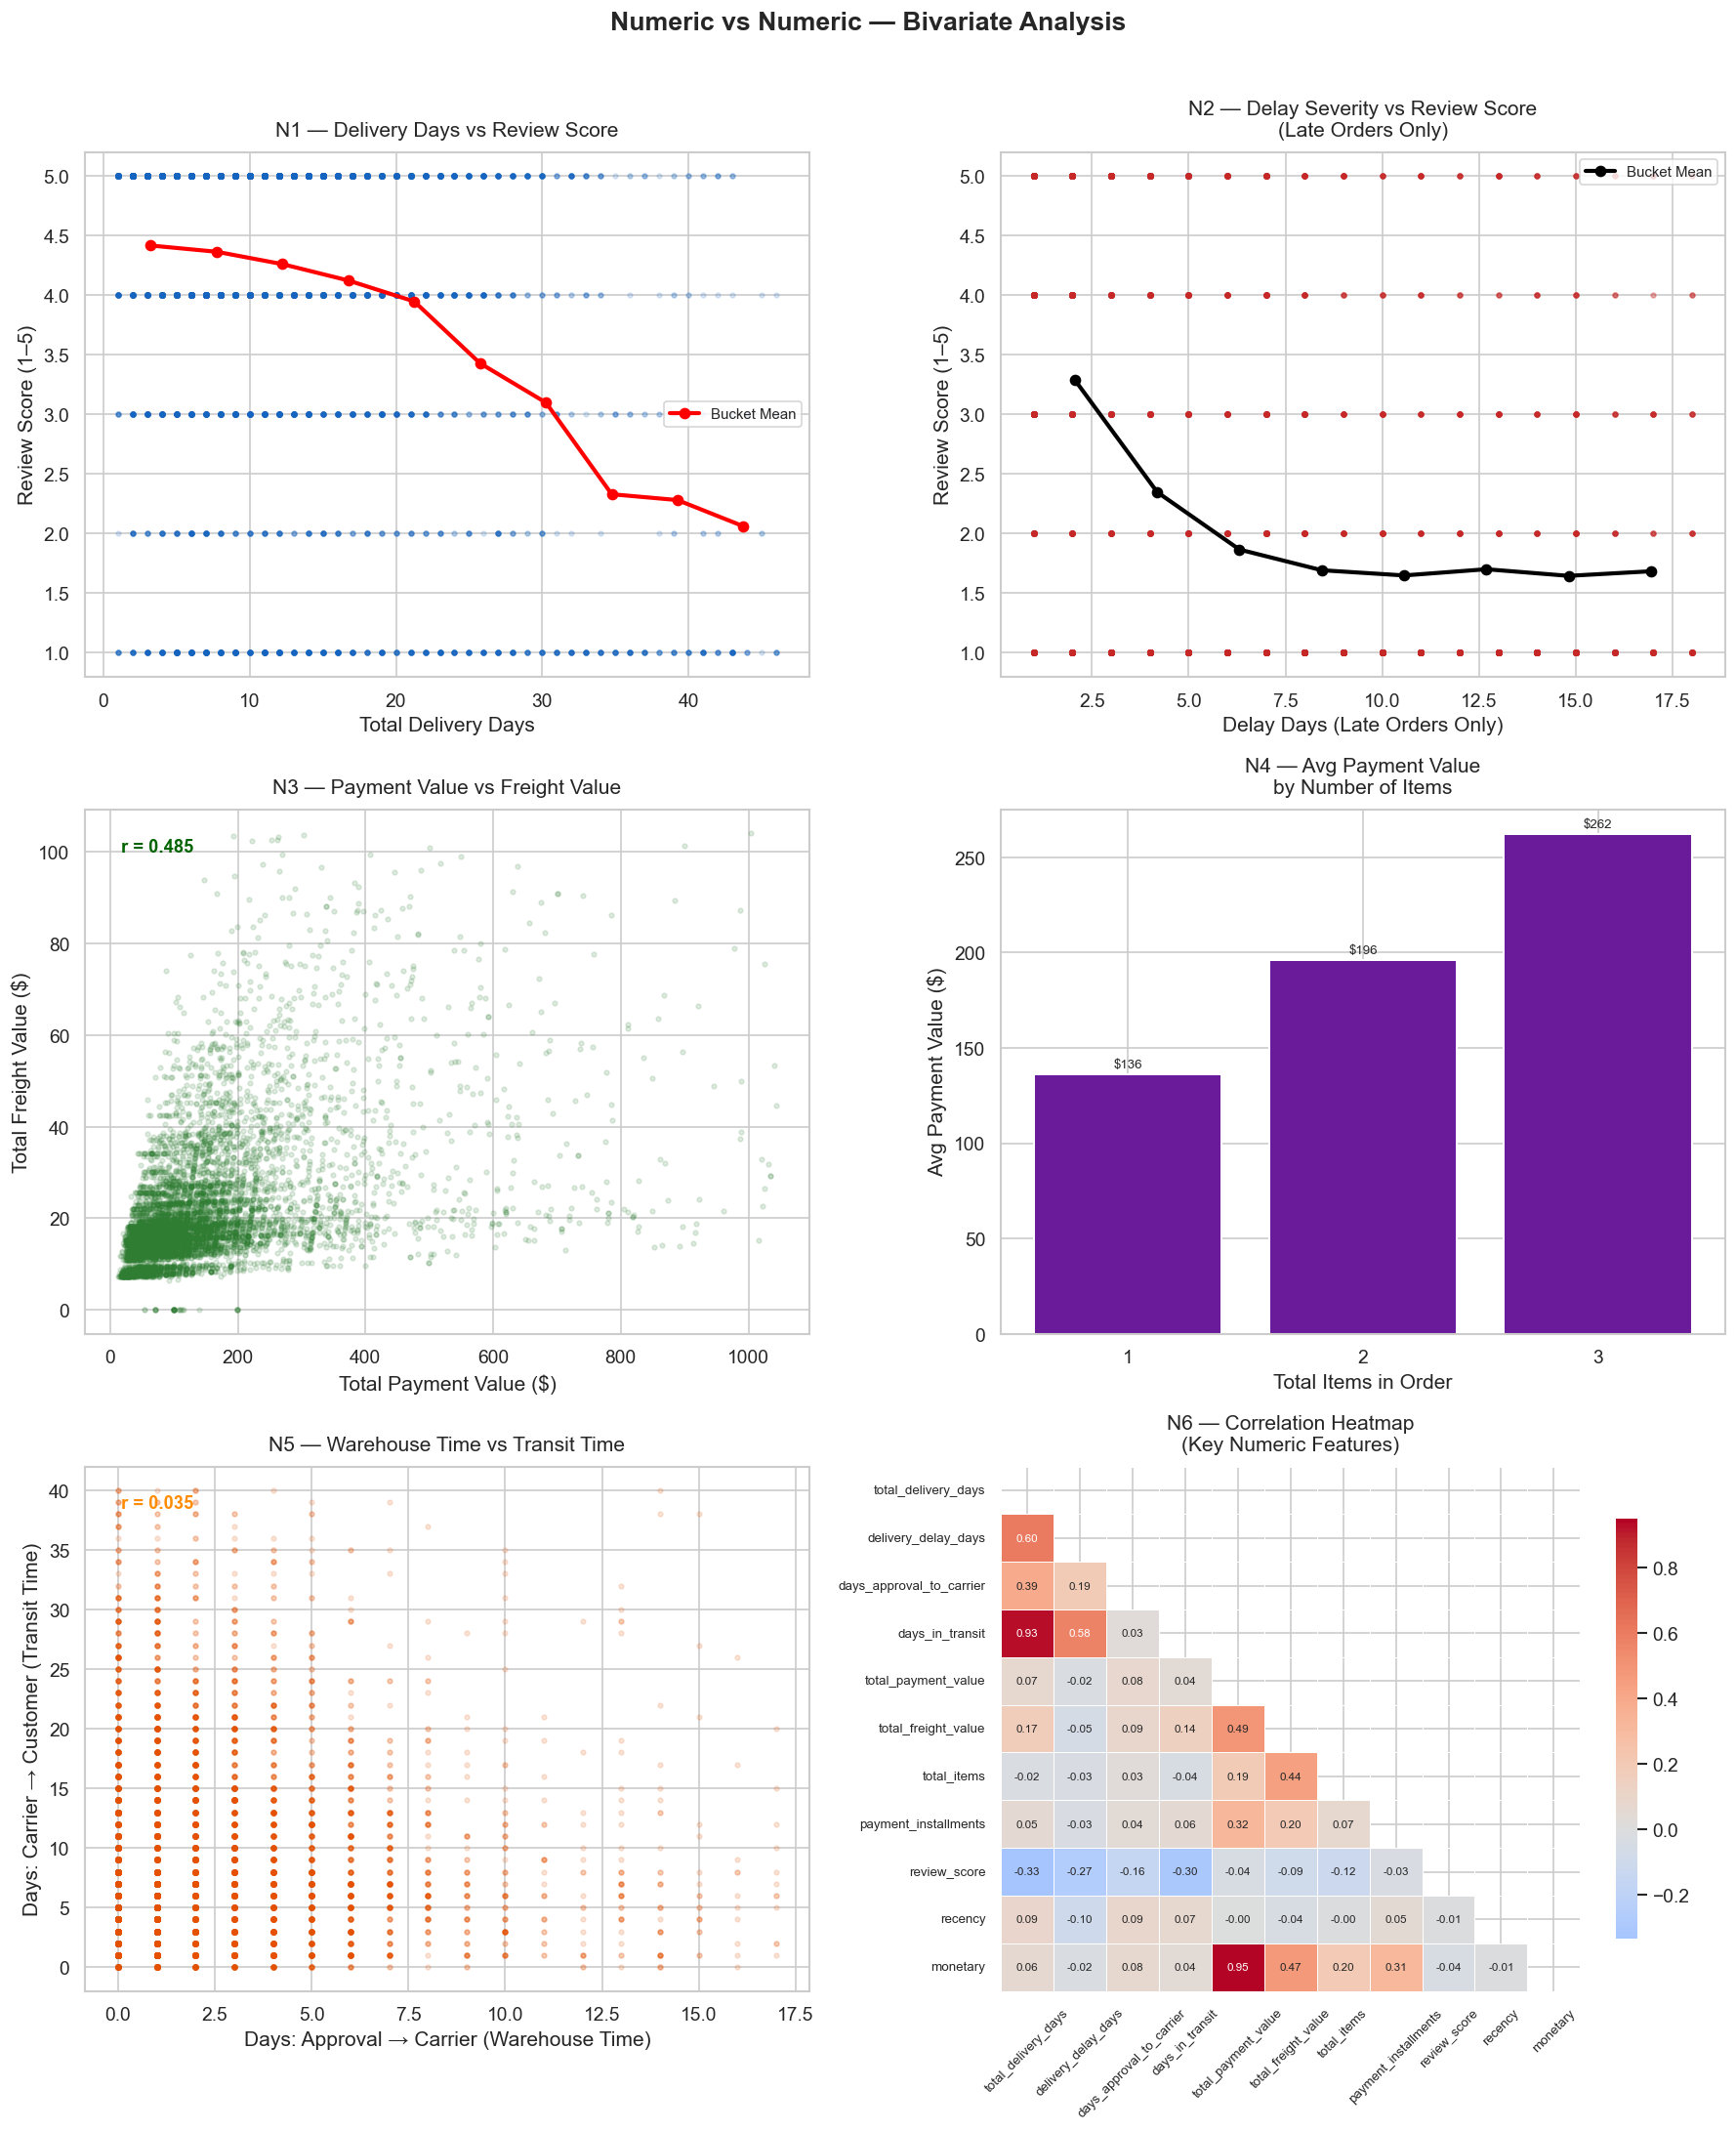

In [33]:
import matplotlib.ticker as mticker

# Global plot style
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlepad': 10})
 
# SECTION 1 — SHARED FILTERS
# Keeping only delivered orders for logistics / experience analysis
# Excluding boleto anomalies & ghost shipments from time calculations
# Excluding boundary months (fringe incomplete months) from trend analysis
 
# Base delivered filter
df_del = df[(df['order_status'] == 'delivered') &
         (df['order_delivered_customer_date'].notna()) &
         (~df['is_boleto_anomaly']) &
         (~df['is_ghost_shipment'])
].copy()
 
# Logistics sub-filter — additionally needs delivery_delay_days computed
df_logistics = df_del[df_del['delivery_delay_days'].notna()].copy()
 
# Step-metric sub-filter — excludes records missing carrier date
# (used for days_approval_to_carrier and days_in_transit)
df_steps = df_logistics[df_logistics['order_delivered_carrier_date'].notna()].copy()
 
# Time trend filter — excludes boundary months (fringe data)
df_trend = df_del[~df['is_boundary_month']].copy()
 
print(f"df_del       : {len(df_del):,} rows  (delivered, no anomalies)")
print(f"df_logistics : {len(df_logistics):,} rows  (+ delay days available)")
print(f"df_steps     : {len(df_steps):,} rows  (+ carrier date available)")
print(f"df_trend     : {len(df_trend):,} rows  (+ boundary months excluded)")
 
# SECTION 2 — NUMERIC vs NUMERIC
# Pairs explored:
#   N1 : total_delivery_days  vs  review_score
#   N2 : delivery_delay_days  vs  review_score      (late orders only)
#   N3 : total_payment_value  vs  total_freight_value
#   N4 : total_payment_value  vs  total_items
#   N5 : days_approval_to_carrier  vs  days_in_transit
#   N6 : Correlation heatmap — all key numeric features
 

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Numeric vs Numeric — Bivariate Analysis', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

# N1 : total_delivery_days vs review_score
# Cap delivery days at 99th percentile to remove extreme outliers
p99_del = df_logistics['total_delivery_days'].quantile(0.99)
n1 = df_logistics[df_logistics['review_score'].notna() &
    (df_logistics['total_delivery_days'] <= p99_del)
].sample(n=min(8000, len(df_logistics)), random_state=42)
 
axes[0].scatter(n1['total_delivery_days'], n1['review_score'], alpha=0.15, s=8, color='#1565C0')
# Overlay mean review score per delivery-day bucket
n1['del_bucket'] = pd.cut(n1['total_delivery_days'], bins=10)
mean_line = n1.groupby('del_bucket', observed=True)['review_score'].mean()
bucket_mids = [interval.mid for interval in mean_line.index]
axes[0].plot(bucket_mids, mean_line.values, color='red', linewidth=2.5, marker='o', markersize=6, label='Bucket Mean')
axes[0].set_xlabel('Total Delivery Days')
axes[0].set_ylabel('Review Score (1–5)')
axes[0].set_title('N1 — Delivery Days vs Review Score')
axes[0].legend(fontsize=9)
 
# N2 : delivery_delay_days vs review_score (late orders only)
p99_delay = df_logistics['delivery_delay_days'].quantile(0.99)
n2 = df_logistics[df_logistics['is_delayed'] &
     df_logistics['review_score'].notna() &
    (df_logistics['delivery_delay_days'] <= p99_delay)
].copy()
 
axes[1].scatter(n2['delivery_delay_days'], n2['review_score'], alpha=0.2, s=8, color='#C62828')
n2['delay_bucket'] = pd.cut(n2['delivery_delay_days'], bins=8)
mean_line2 = n2.groupby('delay_bucket', observed=True)['review_score'].mean()
bucket_mids2 = [interval.mid for interval in mean_line2.index]
axes[1].plot(bucket_mids2, mean_line2.values, color='black', linewidth=2.5, marker='o', markersize=6, label='Bucket Mean')
axes[1].set_xlabel('Delay Days (Late Orders Only)')
axes[1].set_ylabel('Review Score (1–5)')
axes[1].set_title('N2 — Delay Severity vs Review Score\n(Late Orders Only)')
axes[1].legend(fontsize=9)
 
# N3 : total_payment_value vs total_freight_value
p99_pay  = df_del['total_payment_value'].quantile(0.99)
p99_frgt = df_del['total_freight_value'].quantile(0.99)
n3 = df_del[df_del['total_payment_value'].notna() &
     df_del['total_freight_value'].notna() &
    (df_del['total_payment_value'] <= p99_pay) &
    (df_del['total_freight_value'] <= p99_frgt)
].sample(n=min(8000, len(df_del)), random_state=42)
 
axes[2].scatter(n3['total_payment_value'], n3['total_freight_value'], alpha=0.15, s=8, color='#2E7D32')
# Correlation annotation
corr_n3 = n3['total_payment_value'].corr(n3['total_freight_value'])
axes[2].text(0.05, 0.92, f'r = {corr_n3:.3f}',transform=axes[2].transAxes, fontsize=11, color='darkgreen',fontweight='bold')
axes[2].set_xlabel('Total Payment Value ($)')
axes[2].set_ylabel('Total Freight Value ($)')
axes[2].set_title('N3 — Payment Value vs Freight Value')
 
# N4 : total_payment_value vs total_items
# Cap total_items at 99th pct (overwhelmingly 1 item — cap removes rare bulk)
p99_items = df_del['total_items'].quantile(0.99)
n4 = df_del[df_del['total_payment_value'].notna() &
     df_del['total_items'].notna() &
    (df_del['total_payment_value'] <= p99_pay) &
    (df_del['total_items'] <= p99_items)
].copy()
 
mean_pay_per_items = n4.groupby('total_items')['total_payment_value'].mean().reset_index()
axes[3].bar(mean_pay_per_items['total_items'].astype(int), mean_pay_per_items['total_payment_value'],
            color='#6A1B9A', edgecolor='white', linewidth=1.2)

for _, row in mean_pay_per_items.iterrows():
    axes[3].text(row['total_items'], row['total_payment_value'] + 2,
                 f"${row['total_payment_value']:.0f}",
                 ha='center', va='bottom', fontsize=8)
axes[3].set_xlabel('Total Items in Order')
axes[3].set_ylabel('Avg Payment Value ($)')
axes[3].set_title('N4 — Avg Payment Value\nby Number of Items')
axes[3].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
 
# N5 : days_approval_to_carrier vs days_in_transit
p99_appr    = df_steps['days_approval_to_carrier'].quantile(0.99)
p99_transit = df_steps['days_in_transit'].quantile(0.99)
n5 = df_steps[(df_steps['days_approval_to_carrier'] >= 0) &
    (df_steps['days_in_transit'] >= 0) &
    (df_steps['days_approval_to_carrier'] <= p99_appr) &
    (df_steps['days_in_transit'] <= p99_transit)
].sample(n=min(8000, len(df_steps)), random_state=42)
 
axes[4].scatter(n5['days_approval_to_carrier'], n5['days_in_transit'], alpha=0.15, s=8, color='#E65100')
corr_n5 = n5['days_approval_to_carrier'].corr(n5['days_in_transit'])
axes[4].text(0.05, 0.92, f'r = {corr_n5:.3f}', transform=axes[4].transAxes, fontsize=11, color='darkorange', fontweight='bold')
axes[4].set_xlabel('Days: Approval → Carrier (Warehouse Time)')
axes[4].set_ylabel('Days: Carrier → Customer (Transit Time)')
axes[4].set_title('N5 — Warehouse Time vs Transit Time')
 
# N6 : Correlation Heatmap
num_cols = ['total_delivery_days', 'delivery_delay_days', 'days_approval_to_carrier', 'days_in_transit',
            'total_payment_value', 'total_freight_value', 'total_items', 'payment_installments',
            'review_score', 'recency', 'monetary']

# Use df_del, drop rows with any null in selected numeric cols
corr_df = df_del[num_cols].dropna()
corr_matrix = corr_df.corr()
 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[5], annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, linecolor='white', annot_kws={'size': 7},cbar_kws={'shrink': 0.8})
axes[5].set_title('N6 — Correlation Heatmap\n(Key Numeric Features)')
axes[5].tick_params(axis='x', rotation=45, labelsize=8)
axes[5].tick_params(axis='y', rotation=0,  labelsize=8)
 
plt.tight_layout()
plt.show()

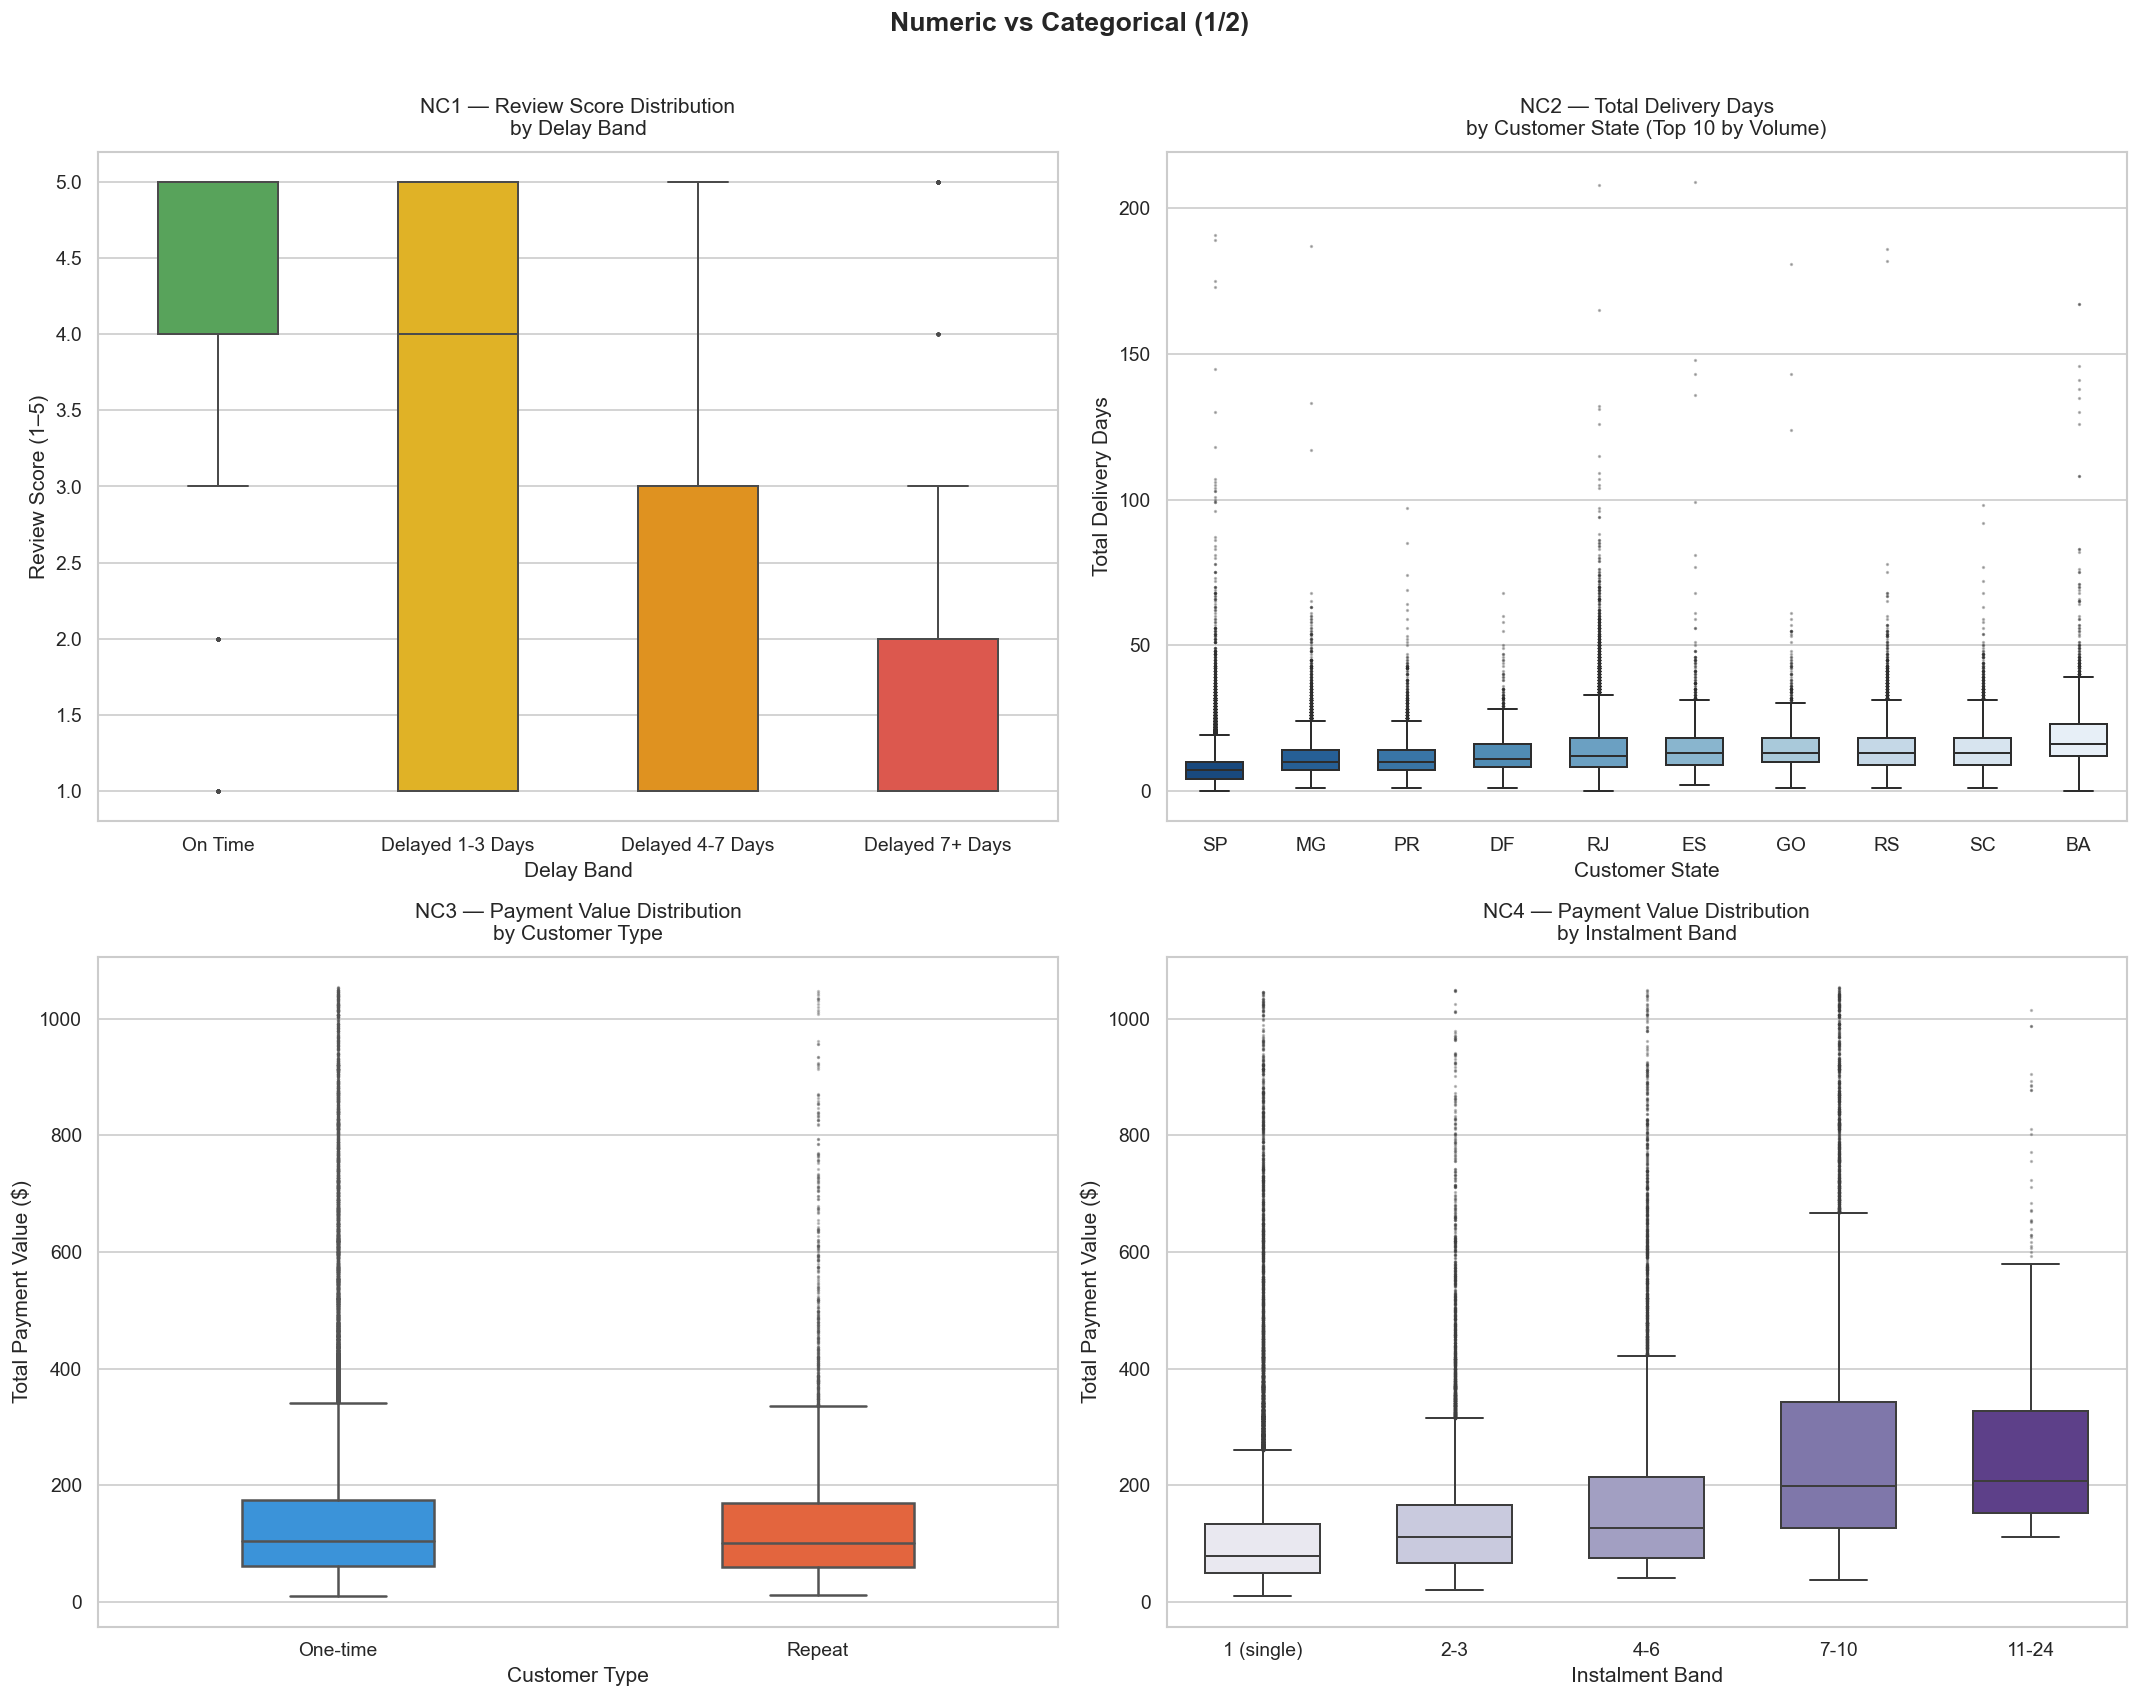

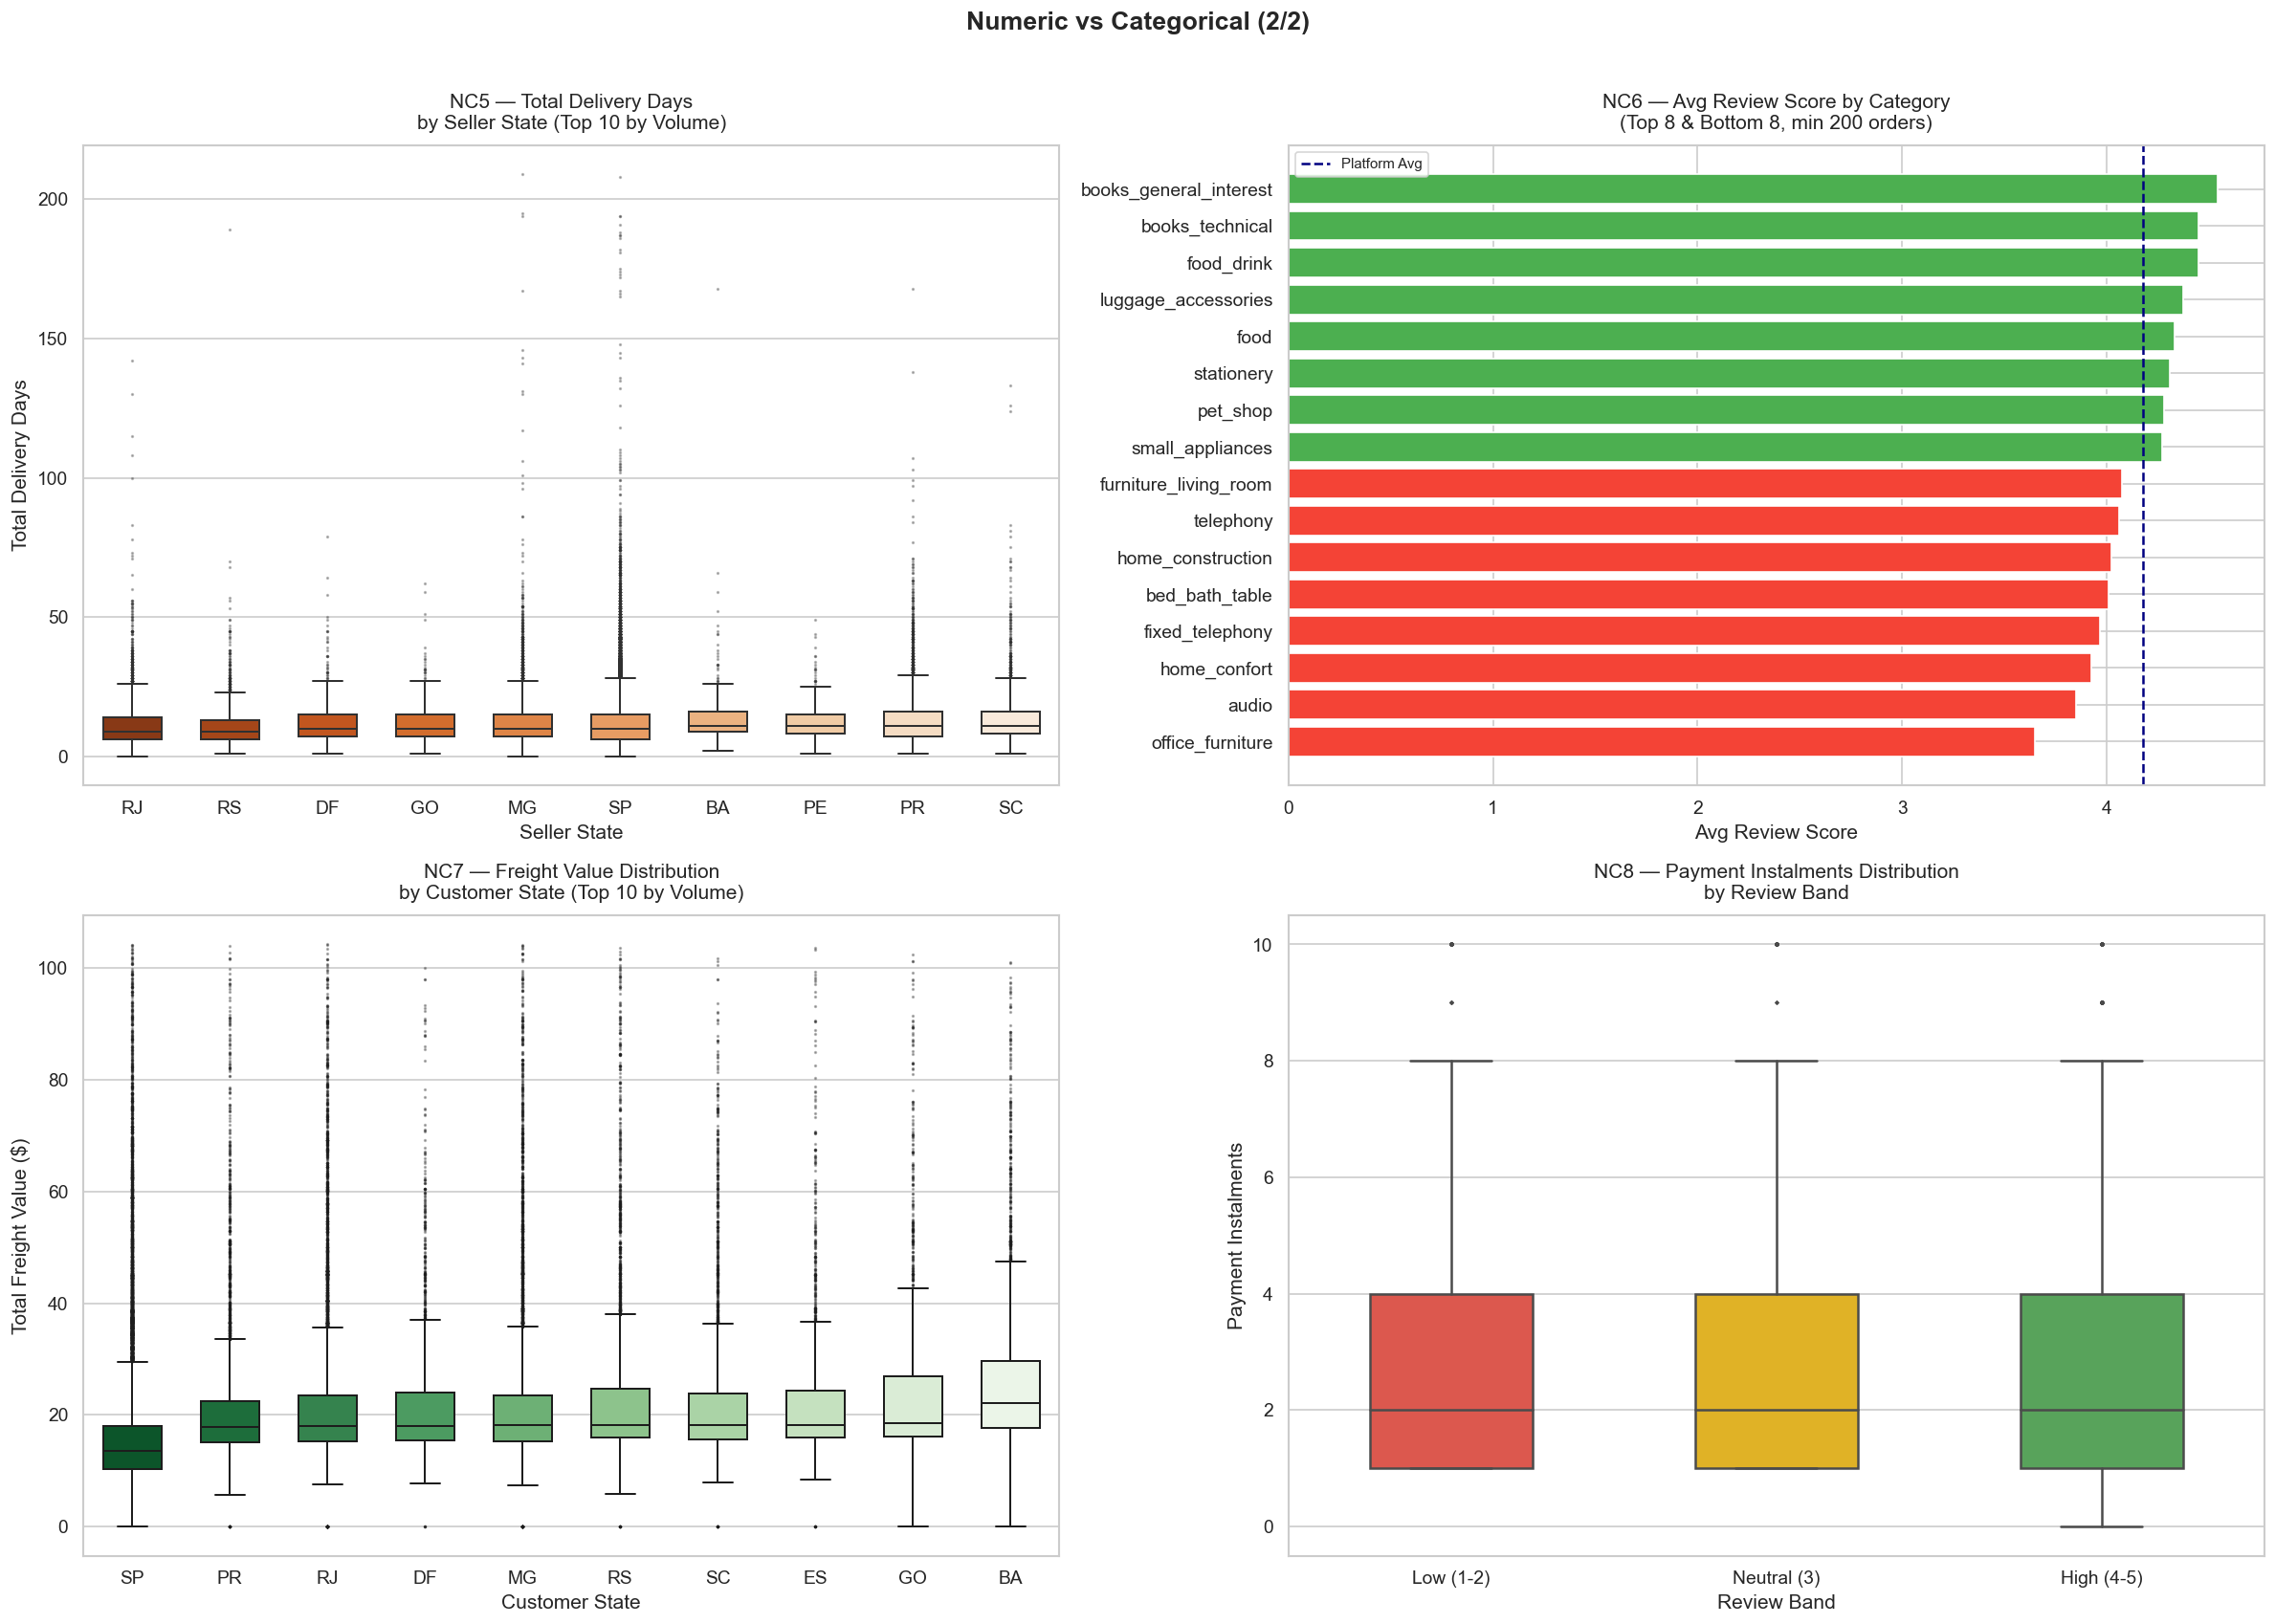

In [36]:
# NUMERIC vs CATEGORICAL
# Pairs explored:
#   NC1 : review_score           by  delay_band
#   NC2 : total_delivery_days    by  customer_state    (Top 10 states)
#   NC3 : total_payment_value    by  customer_type
#   NC4 : total_payment_value    by  instalment_band
#   NC5 : total_delivery_days    by  seller_state      (Top 10 seller states)
#   NC6 : review_score           by  product_category  (Top/Bottom 10)
#   NC7 : total_freight_value    by  customer_state    (Top 10 states)
#   NC8 : payment_installments   by  review_band

delay_band_order = ['On Time', 'Delayed 1-3 Days', 'Delayed 4-7 Days', 'Delayed 7+ Days']

#NC1 : review_score by delay_band — Box plot
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Numeric vs Categorical (1/2)', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()
 
nc1 = df_logistics[df_logistics['review_score'].notna() &
                   df_logistics['delay_band'].notna()
].copy()

delay_palette = {'On Time':          '#4CAF50',
                 'Delayed 1-3 Days': '#FFC107',
                 'Delayed 4-7 Days': '#FF9800',
                 'Delayed 7+ Days':  '#F44336'
}

sns.boxplot(data=nc1, x='delay_band', y='review_score',order=delay_band_order, palette=delay_palette,
            ax=axes[0], width=0.5, linewidth=1.2,flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[0].set_title('NC1 — Review Score Distribution\nby Delay Band')
axes[0].set_xlabel('Delay Band')
axes[0].set_ylabel('Review Score (1–5)')
 
#NC2 : total_delivery_days by customer_state (Top 10 by volume)
top10_states = (df_logistics['customer_state'].value_counts().head(10).index.tolist())
nc2 = df_logistics[df_logistics['customer_state'].isin(top10_states)].copy()
state_order_nc2 = (nc2.groupby('customer_state')['total_delivery_days']
                   .median().sort_values().index.tolist())
sns.boxplot(data=nc2, x='customer_state', y='total_delivery_days', order=state_order_nc2,
            palette='Blues_r', ax=axes[1], width=0.6, linewidth=1.2,flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[1].set_title('NC2 — Total Delivery Days\nby Customer State (Top 10 by Volume)')
axes[1].set_xlabel('Customer State')
axes[1].set_ylabel('Total Delivery Days')
 
#NC3 : total_payment_value by customer_type — Box plot
p99_pay = df_del['total_payment_value'].quantile(0.99)
nc3 = df_del[df_del['total_payment_value'].notna() &
      df_del['customer_type'].notna() &
     (df_del['total_payment_value'] <= p99_pay)
].copy()
sns.boxplot(data=nc3, x='customer_type', y='total_payment_value', palette=['#2196F3', '#FF5722'],
            ax=axes[2], width=0.4, linewidth=1.5, flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[2].set_title('NC3 — Payment Value Distribution\nby Customer Type')
axes[2].set_xlabel('Customer Type')
axes[2].set_ylabel('Total Payment Value ($)')
 
#NC4 : total_payment_value by instalment_band — Box plot
instalment_order = ['1 (single)', '2-3', '4-6', '7-10', '11-24']
nc4 = df_del[df_del['total_payment_value'].notna() &
      df_del['instalment_band'].notna() &
     (df_del['total_payment_value'] <= p99_pay)
].copy()

sns.boxplot(data=nc4, x='instalment_band', y='total_payment_value', order=instalment_order,
            palette='Purples', ax=axes[3], width=0.6, linewidth=1.2,flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[3].set_title('NC4 — Payment Value Distribution\nby Instalment Band')
axes[3].set_xlabel('Instalment Band')
axes[3].set_ylabel('Total Payment Value ($)')
 
plt.tight_layout()
plt.show()
 
#NC5, NC6, NC7, NC8
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Numeric vs Categorical (2/2)', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()
 
#NC5 : total_delivery_days by seller_state (Top 10 seller states)
top10_seller_states = (df_steps['seller_state'].value_counts().head(10).index.tolist())
nc5 = df_steps[df_steps['seller_state'].isin(top10_seller_states)].copy()
state_order_nc5 = (nc5.groupby('seller_state')['total_delivery_days']
                   .median().sort_values().index.tolist())
sns.boxplot(data=nc5, x='seller_state', y='total_delivery_days', order=state_order_nc5,
            palette='Oranges_r', ax=axes[0], width=0.6, linewidth=1.2,flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[0].set_title('NC5 — Total Delivery Days\nby Seller State (Top 10 by Volume)')
axes[0].set_xlabel('Seller State')
axes[0].set_ylabel('Total Delivery Days')
 
#NC6 : review_score by product_category — Mean bar (Top & Bottom 8)
# Min 200 orders for statistical significance
cat_review = (df_del[df_del['review_score'].notna() &
              df_del['product_category_name_en'].notna()]
              .groupby('product_category_name_en')
              .agg(avg_review=('review_score', 'mean'),
              order_count=('order_id', 'count'))
              .reset_index())

cat_review_sig = cat_review[cat_review['order_count'] >= 200]
top8    = cat_review_sig.nlargest(8, 'avg_review')
bottom8 = cat_review_sig.nsmallest(8, 'avg_review')
nc6     = pd.concat([top8, bottom8]).drop_duplicates()
nc6_sorted = nc6.sort_values('avg_review', ascending=True)
 
colors_nc6 = ['#F44336' if v < cat_review_sig['avg_review'].mean()
              else '#4CAF50' for v in nc6_sorted['avg_review']]
axes[1].barh(nc6_sorted['product_category_name_en'],
             nc6_sorted['avg_review'],
             color=colors_nc6, edgecolor='white', linewidth=1.0)
axes[1].axvline(cat_review_sig['avg_review'].mean(), color='navy', linestyle='--', linewidth=1.5, label='Platform Avg')
axes[1].set_title('NC6 — Avg Review Score by Category\n(Top 8 & Bottom 8, min 200 orders)')
axes[1].set_xlabel('Avg Review Score')
axes[1].legend(fontsize=9)
 
#NC7 : total_freight_value by customer_state (Top 10 states)
p99_frgt = df_del['total_freight_value'].quantile(0.99)
nc7 = df_del[df_del['customer_state'].isin(top10_states) &
      df_del['total_freight_value'].notna() &
     (df_del['total_freight_value'] <= p99_frgt)
].copy()

state_order_nc7 = (nc7.groupby('customer_state')['total_freight_value'].median().sort_values().index.tolist())
sns.boxplot(data=nc7, x='customer_state', y='total_freight_value', order=state_order_nc7,
            palette='Greens_r', ax=axes[2], width=0.6, linewidth=1.2, flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[2].set_title('NC7 — Freight Value Distribution\nby Customer State (Top 10 by Volume)')
axes[2].set_xlabel('Customer State')
axes[2].set_ylabel('Total Freight Value ($)')
 
#NC8 : payment_installments by review_band — Box plot
review_band_order = ['Low (1-2)', 'Neutral (3)', 'High (4-5)']
nc8 = df_del[df_del['payment_installments'].notna() &
      df_del['review_band'].isin(review_band_order)
].copy()
p99_inst = nc8['payment_installments'].quantile(0.99)
nc8 = nc8[nc8['payment_installments'] <= p99_inst]
 
sns.boxplot(data=nc8, x='review_band', y='payment_installments', order=review_band_order,
            palette=['#F44336', '#FFC107', '#4CAF50'], ax=axes[3], width=0.5, linewidth=1.5,
            flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[3].set_title('NC8 — Payment Instalments Distribution\nby Review Band')
axes[3].set_xlabel('Review Band')
axes[3].set_ylabel('Payment Instalments')
 
plt.tight_layout()
plt.show()

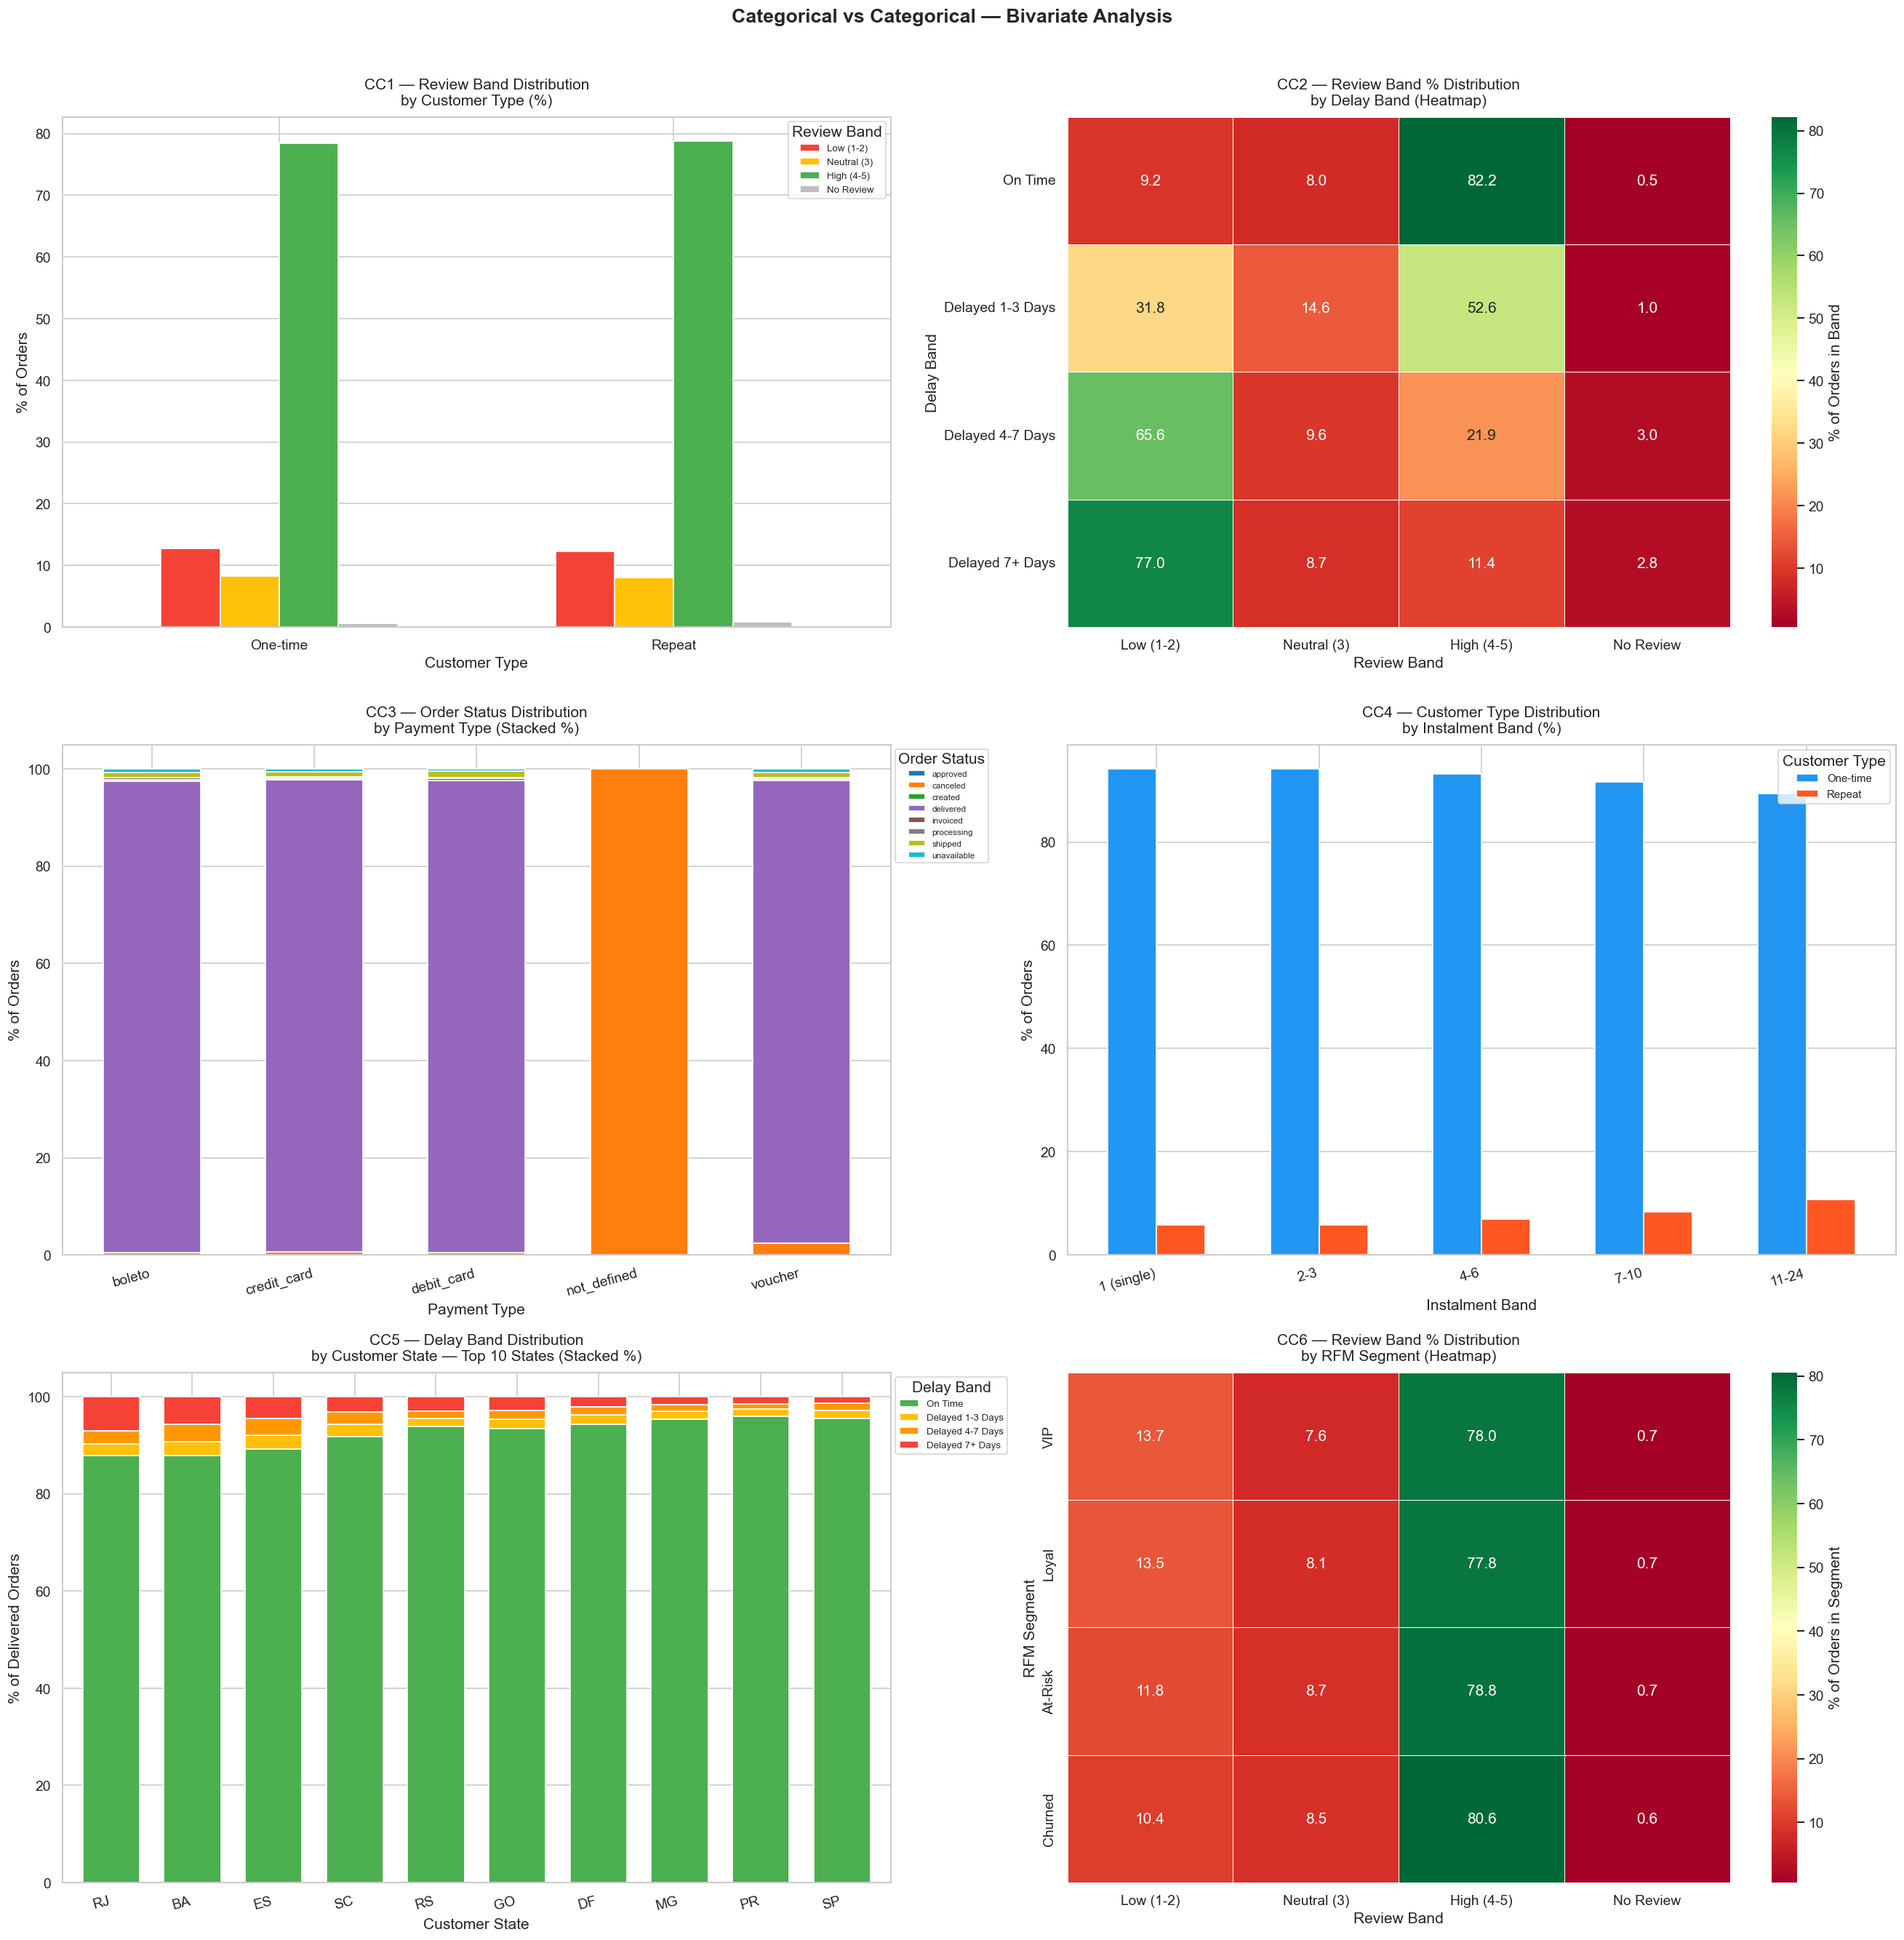

In [38]:
# CATEGORICAL vs CATEGORICAL — Bivariate Analysis
# CC1 : customer_type   vs  review_band
# CC2 : delay_band      vs  review_band
# CC3 : payment_type    vs  order_status
# CC4 : instalment_band vs  customer_type
# CC5 : customer_state  vs  delay_band    (Top 10 states)
# CC6 : rfm_segment     vs  review_band
 
#Defining all labels at the top — must match Feature Engineering exactly
delay_band_order       = ['On Time', 'Delayed 1-3 Days', 'Delayed 4-7 Days', 'Delayed 7+ Days']
review_band_order_full = ['Low (1-2)', 'Neutral (3)', 'High (4-5)', 'No Review']
instalment_order       = ['1 (single)', '2-3', '4-6', '7-10', '11-24']
rfm_order              = ['VIP', 'Loyal', 'At-Risk', 'Churned']
top_payment            = df['payment_type'].value_counts().head(5).index
 
fig, axes = plt.subplots(3, 2, figsize=(22, 22))
fig.suptitle('Categorical vs Categorical — Bivariate Analysis',
             fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()
 
#CC1 : customer_type vs review_band — Grouped % bar
cc1 = (df_del.groupby(['customer_type', 'review_band'])
       .size().unstack('review_band', fill_value=0)
       .reindex(columns=review_band_order_full, fill_value=0))
cc1_pct = cc1.div(cc1.sum(axis=1), axis=0) * 100
cc1_pct.plot(kind='bar', ax=axes[0], width=0.6, edgecolor='white', color=['#F44336', '#FFC107', '#4CAF50', '#BDBDBD'])
axes[0].set_title('CC1 — Review Band Distribution\nby Customer Type (%)')
axes[0].set_xlabel('Customer Type')
axes[0].set_ylabel('% of Orders')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Review Band', fontsize=8, bbox_to_anchor=(1, 1))
 
#CC2 : delay_band vs review_band — % Heatmap
cc2 = (df_logistics[df_logistics['delay_band'].notna() &
       df_logistics['review_band'].isin(review_band_order_full)
].groupby(['delay_band', 'review_band'])
.size().unstack('review_band', fill_value=0)
.reindex(index=delay_band_order, columns=review_band_order_full, fill_value=0))
cc2_pct = cc2.div(cc2.sum(axis=1), axis=0) * 100
 
sns.heatmap(cc2_pct, ax=axes[1], annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of Orders in Band'})
axes[1].set_title('CC2 — Review Band % Distribution\nby Delay Band (Heatmap)')
axes[1].set_xlabel('Review Band')
axes[1].set_ylabel('Delay Band')
 
#CC3 : payment_type vs order_status — Stacked % bar
cc3_raw = (df[df['payment_type'].isin(top_payment)]
           .groupby(['payment_type', 'order_status'])
           .size().unstack('order_status', fill_value=0))
cc3_pct = cc3_raw.div(cc3_raw.sum(axis=1), axis=0) * 100
cc3_pct.plot(kind='bar', stacked=True, ax=axes[2], width=0.6,
             edgecolor='white', colormap='tab10')
axes[2].set_title('CC3 — Order Status Distribution\nby Payment Type (Stacked %)')
axes[2].set_xlabel('Payment Type')
axes[2].set_ylabel('% of Orders')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15, ha='right')
axes[2].legend(title='Order Status', fontsize=7, bbox_to_anchor=(1, 1), loc='upper left')
 
#CC4 : instalment_band vs customer_type — Grouped % bar
cc4 = (df_del[df_del['instalment_band'].notna()]
       .groupby(['instalment_band', 'customer_type'])
       .size().unstack('customer_type', fill_value=0)
       .reindex(instalment_order))
cc4_pct = cc4.div(cc4.sum(axis=1), axis=0) * 100
cc4_pct.plot(kind='bar', ax=axes[3], width=0.6, edgecolor='white', color=['#2196F3', '#FF5722'])
axes[3].set_title('CC4 — Customer Type Distribution\nby Instalment Band (%)')
axes[3].set_xlabel('Instalment Band')
axes[3].set_ylabel('% of Orders')
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation=15, ha='right')
axes[3].legend(title='Customer Type', fontsize=9)
 
#CC5 : customer_state vs delay_band — Stacked % bar (Top 10 states)
cc5 = (df_logistics[df_logistics['customer_state'].isin(top10_states) &
       df_logistics['delay_band'].notna()
].groupby(['customer_state', 'delay_band'])
.size().unstack('delay_band', fill_value=0)
.reindex(columns=delay_band_order, fill_value=0))
cc5_pct = cc5.div(cc5.sum(axis=1), axis=0) * 100
cc5_pct = cc5_pct.sort_values('Delayed 7+ Days', ascending=False)
cc5_pct.plot(kind='bar', stacked=True, ax=axes[4], width=0.7, edgecolor='white', color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'])
axes[4].set_title('CC5 — Delay Band Distribution\nby Customer State — Top 10 States (Stacked %)')
axes[4].set_xlabel('Customer State')
axes[4].set_ylabel('% of Delivered Orders')
axes[4].set_xticklabels(axes[4].get_xticklabels(), rotation=15, ha='right')
axes[4].legend(title='Delay Band', fontsize=8, bbox_to_anchor=(1, 1))
 
#CC6 : rfm_segment vs review_band — % Heatmap
cc6 = (df_del[df_del['rfm_segment'].notna() &
       df_del['review_band'].isin(review_band_order_full)
].groupby(['rfm_segment', 'review_band'])
.size().unstack('review_band', fill_value=0)
.reindex(index=rfm_order, columns=review_band_order_full, fill_value=0))
cc6_pct = cc6.div(cc6.sum(axis=1), axis=0) * 100
 
sns.heatmap(cc6_pct, ax=axes[5], annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of Orders in Segment'})
axes[5].set_title('CC6 — Review Band % Distribution\nby RFM Segment (Heatmap)')
axes[5].set_xlabel('Review Band')
axes[5].set_ylabel('RFM Segment')
 
plt.tight_layout()
plt.show()

**Numeric vs Numeric**

* **N1 — Total Delivery Days vs Review Score**
The bucket mean line shows a clear and consistent downward trend — dropping from ~4.4 stars at 0–5 days delivery down to ~2.0 stars at 35–45 days. Every additional 10 days of delivery costs roughly 0.5 stars in customer satisfaction. Faster delivery is the single strongest driver of positive reviews on the platform.

* **N2 — Delay Severity vs Review Score (Late Orders Only)**
The steepest drop happens immediately — review score crashes from ~3.2 at just 2–3 days late down to ~1.6 at 10+ days late, after which it flattens. The damage is done early. Even a 2–3 day delay causes significant dissatisfaction. Beyond 10 days the score barely worsens — the customer is already maximally unhappy. This means early intervention (alerting customers at day 2–3 of delay) is more valuable than any action taken after day 7.

* **N3 — Payment Value vs Freight Value**
r = 0.485 — moderate positive correlation. Higher value orders tend to attract higher freight charges but the relationship is loose. Freight is partially driven by order value but product size and weight — which vary heavily by category — are equally significant factors. This explains why two orders of the same value can have very different freight costs.
N4 — Avg Payment Value by Number of Items
Clean linear progression — 1 item averages $136, 2 items $196, 3 items $262. Each additional item adds roughly $60 in order value. Since over 90% of orders are single-item, encouraging customers to add even one more item to their cart would directly and meaningfully increase AOV across the platform.

* **N5 — Warehouse Time vs Transit Time**
r = 0.035 — essentially zero correlation. The two delivery legs are completely independent of each other. A seller being slow to dispatch does not predict a slow carrier. These are separate operational problems requiring separate interventions — seller-side SLAs to reduce warehouse time and carrier-side SLAs to reduce transit time. Conflating them in any operational fix would be a mistake.

* **N6 — Correlation Heatmap**
Key relationships across all numeric features:

   * review_score vs total_delivery_days = -0.31 — strongest signal in the dataset, directly confirms the core hypothesis
   * days_in_transit vs total_delivery_days = 0.60 — transit time dominates total delivery time, not warehouse time. Carrier performance is the bigger lever
   * payment_installments vs total_payment_value = 0.32 — higher value orders use more EMI, confirming EMI is a financing tool not a general preference
   * total_payment_value vs total_freight_value = 0.17 — weak relationship, freight is driven more by product dimensions than price
   * Most other pairs are near 0 — no multicollinearity issues in the engineered features, all 21 features are analytically independent

**Numeric vs Categorical**

* **NC1 — Review Score by Delay Band**
The most visually striking chart in the numeric vs categorical section. On Time orders show a wide box — median ~4.5, spread 3–5, reflecting high and consistent satisfaction. Delayed 1-3 Days drops to median 4.0 — still positive but the box compresses, showing growing inconsistency. Delayed 4-7 Days crashes to median 3.0 with a very tight box — customers are consistently giving exactly 3 stars, indicating a predictable dissatisfaction threshold has been crossed. Delayed 7+ Days hits median 2.0 — customers are overwhelmingly unhappy with the box sitting between 1–3. The 4-day mark is the critical SLA threshold — below it customers stay mostly positive, beyond it satisfaction collapses sharply.

* **NC2 — Total Delivery Days by Customer State**
SP is the fastest state — median ~8 days with the tightest box, confirming the SP seller centralization advantage. MG and PR are close behind at ~11–12 days. RJ shows a noticeably wider spread with extreme outliers reaching 75+ days. BA at the far right has a median of ~20 days and the widest box of all top 10 states. Distance from SP drives both slower and less predictable delivery — BA customers face 2.5x longer median delivery than SP customers, a structural disadvantage built into the platform's geography.

* **NC3 — Payment Value by Customer Type**
Both One-time and Repeat customer boxes are nearly identical — median ~Dollar 120–130, similar IQR and whisker range. Repeat customers do not spend more per individual order than one-time customers. The value of a repeat customer comes entirely from purchase frequency, not higher spend per transaction. Any retention strategy must therefore focus on driving a second purchase, not upselling on the first.

* **NC4 — Payment Value by Instalment Band**
Clear stepwise increase across bands — single payment median ~$80, rising steadily to 11–24 instalments median ~$210. Customers specifically choose more instalments for higher-value purchases. EMI is a financing tool for expensive orders, not a general payment preference. This means instalment options are most valuable for high-ticket categories like electronics and furniture — not for the platform's core lifestyle and home-goods categories.

* **NC5 — Total Delivery Days by Seller State**
All top 10 seller states show very similar medians in the 10–15 day range. SC is marginally higher. Seller location has minimal impact on total delivery time. The carrier transit leg — which depends on the customer's location — dominates total delivery time far more than where the seller ships from. Improving seller dispatch speed would have limited impact without also addressing the carrier transit problem for distant customer states.

* **NC6 — Avg Review Score by Product Category**
Top performers — books_general_interest, books_technical, food_drink, luggage_accessories — all sit well above the platform average. These are lightweight, easy-to-ship, low-damage-risk categories where delivery is simple and product expectations are clear. Bottom performers — office_furniture, audio, home_comfort, fixed_telephony — all fall significantly below average. These are bulky, fragile, or technically complex categories where delivery damage, setup complexity, and unmet expectations are more likely. Category type is a reliable predictor of review quality independent of delivery speed.

* **NC7 — Freight Value by Customer State**
SP has the lowest freight median at ~$15. A clear gradient emerges as states move further from SP — GO, RS, SC, ES, BA progressively higher, with BA reaching ~$25+ median freight. Non-SP customers pay 40–60% more in freight than SP customers. This freight premium compounds the satisfaction disadvantage for distant states — they already receive slower and less reliable delivery, and they pay more for it. This dual penalty is a structural contributor to higher dissatisfaction and churn rates outside SP.

* **NC8 — Payment Instalments by Review Band**
All three review bands — Low (1-2), Neutral (3), High (4-5) — show nearly identical instalment distributions with medians around 2 and largely overlapping boxes. Instalment usage has no relationship with review score. Price-sensitive customers using high-EMI plans rate the platform the same as outright purchasers. Satisfaction is driven by delivery experience and product quality, not by how the customer chose to pay.

**Categorical vs Categorical**

* **CC1 — Review Band Distribution by Customer Type**
One-time and Repeat customers show virtually identical review distributions — both approximately 78% High, 12% Low, 9% Neutral, 1% No Review. The bars are indistinguishable. Customer type has zero influence on review behaviour. Repeat customers are neither more forgiving nor more critical than one-time customers. This confirms that satisfaction is purely transaction-driven — each order is evaluated on its own merits regardless of how many times the customer has bought before.

* **CC2 — Review Band % Distribution by Delay Band**
The most important chart in the entire bivariate analysis. The progression is steep and consistent:

   * On Time: 82.2% High, 9.2% Low — platform performs excellently for on-time orders
   * Delayed 1-3 Days: High drops to 52.6%, Low triples to 31.8% — even minor delays cause serious satisfaction damage
   * Delayed 4-7 Days: High collapses to 21.9%, Low skyrockets to 65.6% — majority of customers now dissatisfied
   * Delayed 7+ Days: 77.0% Low, only 11.4% High — near-complete satisfaction collapse

    A customer delayed 7+ days is 8x more likely to give a low rating than an on-time customer. Every delay band roughly doubles the low-rating rate. This is the strongest quantitative proof of the core hypothesis — delivery delay is the primary driver of poor customer experience on the platform.

* **CC3 — Order Status Distribution by Payment Type**
Credit card and debit card are ~97%+ delivered with negligible cancellation rates — real-time payment confirmation eliminates most order failures. Boleto has a clearly visible non-delivered slice — its payment clearing delay creates a window where orders are processed before payment confirms, consistent with the boleto anomaly finding in SQL profiling. Voucher shows the most varied order status distribution. Payment method is a reliable proxy for order completion risk — credit card is lowest risk, boleto is highest.
* **CC4 — Customer Type Distribution by Instalment Band**
One-time customers dominate at 90–95% across every instalment band — 1 single, 2-3, 4-6, 7-10, and 11-24. Repeat customers sit consistently at 5–10% regardless of how many instalments are used. The 11-24 instalment band shows a very marginal uptick in repeat customers but the difference is negligible. Payment flexibility has no relationship to customer retention. The platform cannot increase repeat purchases by offering more instalment options — churn is not a payment friction problem.

* **CC5 — Delay Band Distribution by Customer State**
RJ and BA at the left end of the chart show the largest coloured tops — visibly more red (Delayed 7+ Days) and orange compared to SP on the far right which is almost entirely green. The gradient from worst (RJ, BA) to best (SP) is clear. RJ and BA customers face roughly 2–3x higher severe delay rates than SP customers. This is structural — seller centralization in SP means non-SP deliveries require longer carrier routes with more handoff points and higher failure probability. States further from SP consistently show worse delay profiles across all delay bands, not just the most severe.

* **CC6 — Review Band % Distribution by RFM Segment**
All four RFM segments show remarkably similar and consistently high-quality review distributions:

   * VIP: 78.0% High, 13.7% Low, 7.6% Neutral
   * Loyal: 77.8% High, 13.5% Low, 8.1% Neutral
   * At-Risk: 78.8% High, 11.8% Low, 8.7% Neutral
   * Churned: 80.6% High, 10.4% Low, 8.5% Neutral

Churned customers gave the best reviews of all four segments. This is the most counterintuitive and strategically important finding of the entire analysis. Customers are churning despite being satisfied — not because of bad experience. This fundamentally challenges and refines the original hypothesis. Olist's churn problem is structural, not experiential — customers complete their purchase intent, buy what they needed, and have no natural reason to return. Fixing delivery or service quality alone will not solve retention. The platform requires demand generation strategy — cross-sell recommendations, re-engagement campaigns, new category discovery — to create a reason for satisfied customers to return.

In [39]:
# EXPORTING — Final Enriched Master DataFrame
 
#Dropping columns not needed in Tableau
# purchase_month was a temp column used only for univariate time analysis
# del_bucket, delay_bucket, payment_bucket were temp binning columns in bivariate
cols_to_drop = ['purchase_month', 'del_bucket', 'delay_bucket', 'payment_bucket']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]  # only drop if exists
df_export = df.drop(columns=cols_to_drop).copy()
 
#Final shape and column check
print("=== EXPORT VALIDATION ===")
print(f"Shape         : {df_export.shape[0]:,} rows  ×  {df_export.shape[1]} columns")
print(f"\nAll Columns ({df_export.shape[1]}):")
for i, col in enumerate(df_export.columns, 1):
    print(f"  {i:>2}. {col}")
 
#Checking no critical columns are missing
required_cols = [
    # Original master columns
    'customer_unique_id', 'customer_state', 'order_id', 'order_status',
    'order_purchase_timestamp', 'total_payment_value', 'total_freight_value',
    'total_items', 'payment_type', 'payment_installments', 'review_score',
    'product_category_name_en', 'seller_state', 'primary_seller_id',
    # Engineered features F1–F21
    'total_delivery_days', 'delivery_delay_days', 'is_delayed',
    'days_approval_to_carrier', 'days_in_transit', 'delay_band',
    'is_premature_review', 'review_band', 'customer_order_count',
    'customer_type', 'days_between_orders', 'is_boleto_anomaly',
    'is_ghost_shipment', 'recency', 'frequency', 'monetary',
    'rfm_segment', 'acquisition_month', 'is_boundary_month',
    'cohort_index', 'instalment_band'
]
 
missing = [c for c in required_cols if c not in df_export.columns]
if missing:
    print(f"\n⚠️  Missing columns: {missing}")
else:
    print(f"\n✅ All {len(required_cols)} required columns present")
 
#Null summary for key columns
print("\nNull counts for key columns:")
key_null_check = ['total_delivery_days', 'delivery_delay_days', 'delay_band',
                  'review_score', 'review_band', 'customer_type', 'rfm_segment',
                  'instalment_band', 'cohort_index']
for col in key_null_check:
    if col in df_export.columns:
        nulls = df_export[col].isna().sum()
        print(f"  {col:<30}: {nulls:,} nulls")
 
#Export 
export_path = 'olist_master_enriched.csv'
df_export.to_csv(export_path, index=False)
print(f"\n✅ Exported successfully → {export_path}")
print(f"   {df_export.shape[0]:,} rows  ×  {df_export.shape[1]} columns")
print("\nNext step → Load olist_master_enriched.csv into Tableau")

=== EXPORT VALIDATION ===
Shape         : 99,252 rows  ×  58 columns

All Columns (58):
   1. customer_id
   2. customer_unique_id
   3. customer_zip_code
   4. customer_city
   5. customer_state
   6. order_id
   7. order_status
   8. order_purchase_timestamp
   9. order_approved_at
  10. order_delivered_carrier_date
  11. order_delivered_customer_date
  12. order_estimated_delivery_date
  13. total_payment_value
  14. payment_type
  15. payment_installments
  16. payment_rows
  17. total_items
  18. total_items_price
  19. total_freight_value
  20. primary_seller_id
  21. primary_product_id
  22. seller_zip_code
  23. seller_city
  24. seller_state
  25. product_category_name_pt
  26. product_category_name_en
  27. product_weight_gm
  28. product_photos_qty
  29. product_name_length
  30. product_description_length
  31. review_score
  32. review_creation_date
  33. customer_lat
  34. customer_lng
  35. total_delivery_days
  36. delivery_delay_days
  37. is_delayed
  38. days_approva